# Loading VLM Models in Scratch

In [1]:
# === Set cache to scratch before importing transformers ===
import os

# Define the path to store Hugging Face cache
cache_dir = "/scratch/klimbu2/huggingface"

# Create the directory if it doesn't exist
os.makedirs(cache_dir, exist_ok=True)

# Set the environment variables to use the scratch directory
os.environ["HF_HOME"] = cache_dir
os.environ["HUGGINGFACE_HUB_CACHE"] = os.path.join(cache_dir, "hub")
os.environ["TRANSFORMERS_CACHE"] = os.path.join(cache_dir, "transformers")

# Print environment variables to verify if they are set correctly
print("HF_HOME is set to:", os.getenv("HF_HOME"))
print("HUGGINGFACE_HUB_CACHE is set to:", os.getenv("HUGGINGFACE_HUB_CACHE"))
print("TRANSFORMERS_CACHE is set to:", os.getenv("TRANSFORMERS_CACHE"))

HF_HOME is set to: /scratch/klimbu2/huggingface
HUGGINGFACE_HUB_CACHE is set to: /scratch/klimbu2/huggingface/hub
TRANSFORMERS_CACHE is set to: /scratch/klimbu2/huggingface/transformers


In [2]:
import sys
print(sys.executable)

/opt/sw/spack/apps/linux-rhel8-x86_64_v2/gcc-10.3.0/python-3.9.9-jh/bin/python3.9


In [3]:
# BLIP-1
from transformers import BlipProcessor, BlipForConditionalGeneration
BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

/home/klimbu2/.local/lib/python3.9/site-packages/transformers/utils/hub.py:105: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
/home/klimbu2/.local/lib/python3.9/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


BlipForConditionalGeneration(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-0

In [4]:
# ViT + GPT2 (CNN + Transformer hybrid baseline)
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
VisionEncoderDecoderModel.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning")
AutoTokenizer.from_pretrained("nlpconnect/vit-gpt2-image-captioning")

Config of the encoder: <class 'transformers.models.vit.modeling_vit.ViTModel'> is overwritten by shared encoder config: ViTConfig {
  "architectures": [
    "ViTModel"
  ],
  "attention_probs_dropout_prob": 0.0,
  "encoder_stride": 16,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-12,
  "model_type": "vit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "pooler_act": "tanh",
  "pooler_output_size": 768,
  "qkv_bias": true,
  "torch_dtype": "float32",
  "transformers_version": "4.51.3"
}

Config of the decoder: <class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'> is overwritten by shared decoder config: GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": true,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "decoder_start_to

GPT2TokenizerFast(name_or_path='nlpconnect/vit-gpt2-image-captioning', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>', 'pad_token': '<|endoftext|>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [5]:
# CLIP (for scoring / visual-semantic grounding reference)
from transformers import CLIPProcessor, CLIPModel
CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
CLIPModel.from_pretrained("openai/clip-vit-base-patch32")

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [6]:
# BLIP-2 (InstructBLIP - Vicuna 13B)
# from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
# InstructBlipProcessor.from_pretrained("Salesforce/instructblip-vicuna-13b")
# InstructBlipForConditionalGeneration.from_pretrained("Salesforce/instructblip-vicuna-13b")

# BLIP-2 Instruct BLIP

In [7]:
# !ls /scratch/klimbu2/huggingface/transformers/models--Salesforce--instructblip-vicuna-13b/snapshots

In [8]:
# from transformers import InstructBlipProcessor, InstructBlipForConditionalGeneration
# import torch
# from PIL import Image
# import matplotlib.pyplot as plt

# # === Load Model from Scratch Path ===
# model_path = "/scratch/klimbu2/huggingface/transformers/models--Salesforce--instructblip-vicuna-13b/snapshots/91271ed4920607b735c9925dfa495de6d012d16d"

# processor = InstructBlipProcessor.from_pretrained(model_path)
# model = InstructBlipForConditionalGeneration.from_pretrained(
#     model_path,
#     torch_dtype=torch.float16,
#     device_map="auto"
# )

# # === Load Image ===
# image_path = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/images/ROCO_00012.jpg"
# image = Image.open(image_path).convert("RGB")

# # === Display Image ===
# plt.imshow(image)
# plt.axis("off")
# plt.title("Input Medical Image")
# plt.show()

# # === Generate Caption ===
# prompt = "Question: Describe the clinical findings in this medical scan.\nAnswer:"

# inputs = processor(images=image, text=prompt, return_tensors="pt").to(model.device)
# outputs = model.generate(**inputs, max_new_tokens=128)

# caption = processor.batch_decode(outputs, skip_special_tokens=True)[0].strip()
# print("Caption:", caption)

# CLIP

In [9]:
!ls /scratch/klimbu2/huggingface/transformers/models--openai--clip-vit-base-patch32/snapshots

3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268
a68f74976de48b74d683037f8407f464f63e3d09


In [10]:
from transformers import CLIPProcessor, CLIPModel
import torch
from PIL import Image
import os

os.environ["TRANSFORMERS_OFFLINE"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

clip_path = "/scratch/klimbu2/huggingface/transformers/models--openai--clip-vit-base-patch32/snapshots/3d74acf9a28c67741b2f4f2ea7635f0aaf6f0268"

model = CLIPModel.from_pretrained(clip_path).to("cuda" if torch.cuda.is_available() else "cpu")
processor = CLIPProcessor.from_pretrained(clip_path)

# === Load image and sample caption ===
image_path = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/images/ROCO_00015.jpg"
image = Image.open(image_path).convert("RGB")

caption = "An MRI scan showing a sagittal view of the brain"

# === Encode & Score ===
inputs = processor(text=[caption], images=image, return_tensors="pt", padding=True).to(model.device)
outputs = model(**inputs)

# cosine similarity between image and text
image_embeds = outputs.image_embeds
text_embeds = outputs.text_embeds

similarity = torch.nn.functional.cosine_similarity(image_embeds, text_embeds)
print(f"CLIP Similarity Score: {similarity.item():.4f}")

CLIP Similarity Score: 0.2555


# ViT + GPT2 (CNN + Transformer hybrid baseline)/ CLIPCLAP

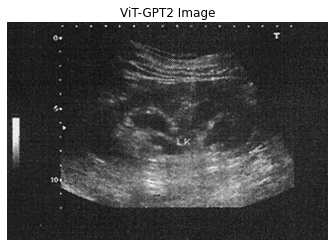

ViT-GPT2 Caption: a black and white photo of a black and white checkered table 


In [20]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
import torch
from PIL import Image
import matplotlib.pyplot as plt
import os

# Model ID - cached in scratch already
model_id = "nlpconnect/vit-gpt2-image-captioning"

# Load model from Hugging Face using local cache
model = VisionEncoderDecoderModel.from_pretrained(model_id, local_files_only=True).to("cuda" if torch.cuda.is_available() else "cpu")
feature_extractor = ViTImageProcessor.from_pretrained(model_id, local_files_only=True)
tokenizer = AutoTokenizer.from_pretrained(model_id, local_files_only=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()


image_path = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/images/ROCO_00015.jpg"
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title("ViT-GPT2 Image")
plt.show()

pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values.to(model.device)
output_ids = model.generate(pixel_values, max_length=128, num_beams=4)
caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

print("ViT-GPT2 Caption:", caption)

# ViT + GPT2 Evaluation

In [21]:
import os
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Allows PIL to load broken images

# --- Load ground truth captions from .txt file ---
def load_roco_captions(txt_path):
    gt = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                image_id, caption = parts
                if caption.strip():  # Ensure caption isn't empty
                    gt[image_id + ".jpg"] = caption.strip()
    return gt

# Paths
# image_path = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/images/ROCO_00012.jpg"
# image = Image.open(image_path).convert("RGB")
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# Load captions
gt_captions = load_roco_captions(captions_txt_path)
image_list = [
    fname for fname in gt_captions.keys()
    if os.path.exists(os.path.join(image_dir, fname))
]

print("Sample keys in gt_captions:", list(gt_captions.keys())[:5])
print("Sample image filename:", image_list[0])

Sample keys in gt_captions: ['ROCO_00001.jpg', 'ROCO_00006.jpg', 'ROCO_00016.jpg', 'ROCO_00025.jpg', 'ROCO_00031.jpg']
Sample image filename: ROCO_00001.jpg


In [22]:
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, AutoTokenizer
from PIL import Image
from tqdm import tqdm
import torch
import os
import json

# === Store predictions and references ===
generated = {}
references = {}

# === Generate captions for each image ===
for fname in tqdm(image_list):
    try:
        img_path = os.path.join(image_dir, fname)
        image = Image.open(img_path).convert("RGB")

        pixel_values = feature_extractor(images=image, return_tensors="pt").pixel_values.to(device)
        output_ids = model.generate(pixel_values, max_length=128, num_beams=4)
        caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        print(fname)
        print(caption)
        ## Save predictions and references
        generated[fname] = [caption]
        references[fname] = [gt_captions[fname]]
       
    except Exception as e:
        print(f"Error processing {fname}: {e}")
    
    
    
with open("vit_gpt2_generated_captions.json", "w") as f:
    json.dump(generated, f)

# with open("reference_captions.json", "w") as f:
#     json.dump(references, f)

  0%|          | 1/8176 [00:00<25:54,  5.26it/s]

ROCO_00001.jpg
a statue of a man sitting on top of a table 


  0%|          | 3/8176 [00:00<24:48,  5.49it/s]

ROCO_00006.jpg
a very close up view of some kind of animal figurine 
ROCO_00016.jpg
a close up picture of an animal's face 


  0%|          | 4/8176 [00:00<25:10,  5.41it/s]

...

ROCO_81770.jpg
a painting of two people on a boat 
ROCO_81771.jpg
a blurry photo of a person on a skateboard 


100%|█████████▉| 8174/8176 [35:10<00:00,  5.35it/s]

ROCO_81778.jpg
a close up view of an animal's face 
ROCO_81792.jpg
a close up view of someones head 


100%|██████████| 8176/8176 [35:11<00:00,  3.87it/s]

ROCO_81796.jpg
a blue and white object is in the shape of a fish 
ROCO_81798.jpg
a statue of a man on a bicycle 


In [23]:
with open("vit_gpt2_generated_captions.json", "r") as gen_f:
    generated = json.load(gen_f)

with open("reference_captions.json", "r") as ref_f:
    references = json.load(ref_f)

In [24]:
import os
import sys
import json
import torch
import logging
import warnings
import tempfile
import contextlib
from tqdm import tqdm
from numpy import ndarray
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from bert_score import score

# === COCOEvalCap (CIDEr & SPICE only) ===
from pycocoevalcap.eval import COCOEvalCap
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocotools.coco import COCO
import io

# Suppress warnings & transformers logs
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# === Bio_ClinicalBERT Setup ===
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# === Sentence Embedding Function (mean-pooled) ===
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden = outputs.last_hidden_state
    mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
    masked = last_hidden * mask
    summed = masked.sum(1)
    counts = mask.sum(1)
    mean_pooled = summed / counts
    return mean_pooled.squeeze().cpu().numpy()

# === Inputs: preds, refs ===
# Replace with your actual values
preds = [generated[k][0] for k in image_list]
refs = [references[k][0] for k in image_list]

# === Cosine Similarity (Mean-Pooled Bio_ClinicalBERT) ===
similarities = []
for pred, ref in tqdm(zip(preds, refs), total=len(preds), desc="Bio_ClinicalBERT Cosine"):
    try:
        emb_pred = get_embedding(pred)
        emb_ref = get_embedding(ref)
        if isinstance(emb_pred, ndarray) and isinstance(emb_ref, ndarray) and emb_pred.shape == emb_ref.shape:
            sim = cosine_similarity([emb_pred], [emb_ref])[0][0]
        else:
            sim = 0.0
    except:
        sim = 0.0
    similarities.append(sim)
bio_clinical_cosine = sum(similarities) / len(similarities)

# === BERTScore (Bio_ClinicalBERT & Original) ===
def truncate_to_512(texts, tokenizer):
    return [tokenizer.convert_tokens_to_string(tokenizer.tokenize(t)[:510]) for t in texts]

preds_trunc = truncate_to_512(preds, tokenizer)
refs_trunc = truncate_to_512(refs, tokenizer)

P_Bio, R_Bio, F1_Bio = score(
    preds_trunc, refs_trunc,
    model_type=model_name,
    num_layers=12,
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

P_BERT, R_BERT, F1_BERT = score(
    preds, refs,
    model_type="bert-base-uncased",
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

pred_dict = {str(i): [pred] for i, pred in enumerate(preds)}
ref_dict  = {str(i): [ref] for i, ref in enumerate(refs)}

def prepare_coco_format(pred_dict, ref_dict):
    ann = {'annotations': [], 'images': [], 'type': 'captions', 'info': {}, 'licenses': []}
    for image_id in ref_dict:
        ann['images'].append({'id': image_id})
        for idx, caption in enumerate(ref_dict[image_id]):
            ann['annotations'].append({
                'image_id': image_id,
                'id': int(f"{image_id}{idx}"),
                'caption': caption
            })
    return ann, [{'image_id': k, 'caption': v[0]} for k, v in pred_dict.items()]

ann_file, res_file = tempfile.NamedTemporaryFile(delete=False), tempfile.NamedTemporaryFile(delete=False)
with open(ann_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[0], f)
with open(res_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[1], f)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    coco = COCO(ann_file.name)
    cocoRes = coco.loadRes(res_file.name)
    
tokenizer = PTBTokenizer()
coco.evalImgs = []
cocoEval = COCOEvalCap(coco, cocoRes)
cocoEval.params['eval'] = ['CIDEr', 'SPICE']

# === Suppress COCOEvalCap stdout/stderr ===
@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

with suppress_stdout_stderr():
    cocoEval.evaluate()

# === Final Clean Output ===
print(f"\n--- Evaluation Summary for ViT + GPT2 Model---")
print(f"Bio_ClinicalBERT Cosine Similarity (Mean Pooled): {bio_clinical_cosine:.4f}")
print(f"BERTScore with Bio_ClinicalBERT:\n"
      f"\tPrecision: {P_Bio.mean():.4f}\n"
      f"\tRecall:    {R_Bio.mean():.4f}\n"
      f"\tF1-Score:  {F1_Bio.mean():.4f}")
print(f"Original BERTScore:\n"
      f"\tPrecision: {P_BERT.mean():.4f}\n"
      f"\tRecall:    {R_BERT.mean():.4f}\n"
      f"\tF1-Score:  {F1_BERT.mean():.4f}")
print(f"CIDEr: {cocoEval.eval['CIDEr']:.4f}")
print(f"SPICE: {cocoEval.eval['SPICE']:.4f}")

# === Cleanup
os.unlink(ann_file.name)
os.unlink(res_file.name)

Bio_ClinicalBERT Cosine: 100%|██████████| 8176/8176 [01:58<00:00, 68.90it/s]
May 07, 2025 11:46:41 AM edu.stanford.nlp.process.PTBLexer next
PTBTokenizer tokenized 200345 tokens at 1016312.94 tokens per second.
PTBTokenizer tokenized 129915 tokens at 1081493.44 tokens per second.
Parsing reference captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.4 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pi

SPICE evaluation took: 15.16 min

--- Evaluation Summary for ViT + GPT2 Model---
Bio_ClinicalBERT Cosine Similarity (Mean Pooled): 0.8051
BERTScore with Bio_ClinicalBERT:
	Precision: 0.6794
	Recall:    0.6368
	F1-Score:  0.6566
Original BERTScore:
	Precision: 0.3863
	Recall:    0.3259
	F1-Score:  0.3520
CIDEr: 0.0052
SPICE: 0.0048


In [25]:
# === BLEU, ROUGE, METEOR ===
import evaluate

bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")
rouge = evaluate.load("rouge")

ref_flat = [r[0] for r in refs]
pred_flat = preds

print("\n⏳ Running BLEU, METEOR, ROUGE...")
bleu_result = bleu.compute(predictions=pred_flat, references=[[r] for r in ref_flat])
meteor_result = meteor.compute(predictions=pred_flat, references=ref_flat)
rouge_result = rouge.compute(predictions=pred_flat, references=ref_flat)

# === CLIP Similarity ===
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from tqdm import tqdm

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").eval().to("cuda" if torch.cuda.is_available() else "cpu")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

clip_scores = []

print("\n⏳ Running CLIP Similarity (CLIPScore)...")
for fname in tqdm(image_list, desc="CLIP Similarity"):
    try:
        image = Image.open(os.path.join(image_dir, fname)).convert("RGB")
        caption = generated[fname][0]

        inputs = clip_processor(text=[caption], images=image, return_tensors="pt", padding=True).to(clip_model.device)

        with torch.no_grad():
            outputs = clip_model(**inputs)
            image_emb = outputs.image_embeds
            text_emb = outputs.text_embeds
            sim = cosine_similarity(image_emb.cpu().numpy(), text_emb.cpu().numpy())[0][0]
            clip_scores.append(sim)

    except Exception as e:
        print(f"Error on {fname}: {e}")
        clip_scores.append(0.0)

clip_score_mean = np.mean(clip_scores)

# === Final Clean Output ===
print(f"\n--- Evaluation Summary for ViT+GPT2 ---")
print(f"BLEU Score:  {bleu_result['bleu']:.4f}")
print(f"METEOR:      {meteor_result['meteor']:.4f}")
print(f"ROUGE-L:     {rouge_result['rougeL']:.4f}")
print(f"CLIP Similarity (CLIPScore): {clip_score_mean:.4f}")

[nltk_data] Downloading package wordnet to /home/klimbu2/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/klimbu2/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /home/klimbu2/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



⏳ Running BLEU, METEOR, ROUGE...

⏳ Running CLIP Similarity (CLIPScore)...


CLIP Similarity:   0%|          | 5/8176 [00:00<03:01, 44.97it/s]

Error on ROCO_00084.jpg: Sequence length must be less than max_position_embeddings (got `sequence length`: 129 and max_position_embeddings: 77


CLIP Similarity:   0%|          | 29/8176 [00:00<02:34, 52.68it/s]

...

Error on ROCO_81108.jpg: Sequence length must be less than max_position_embeddings (got `sequence length`: 129 and max_position_embeddings: 77
Error on ROCO_81132.jpg: Sequence length must be less than max_position_embeddings (got `sequence length`: 129 and max_position_embeddings: 77


CLIP Similarity: 100%|█████████▉| 8142/8176 [02:36<00:00, 51.86it/s]

Error on ROCO_81463.jpg: Sequence length must be less than max_position_embeddings (got `sequence length`: 129 and max_position_embeddings: 77


CLIP Similarity: 100%|██████████| 8176/8176 [02:36<00:00, 52.10it/s]


--- Evaluation Summary for ViT+GPT2 ---
BLEU Score:  0.0000
METEOR:      0.0360
ROUGE-L:     0.0246
CLIP Similarity (CLIPScore): 0.1860


# BLIP (baseline)

In [20]:
!ls /scratch/klimbu2/huggingface/transformers/models--Salesforce--blip-image-captioning-base/snapshots

82a37760796d32b1411fe092ab5d4e227313294b
c39c905a1ac68f0ee42ce3b85d8d983b16d884a7


## BLIP base -> Caption Generation: 

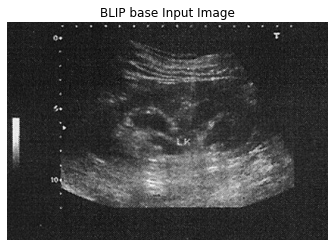

BLIP base Caption: a medical scan of a patient ' s breast


In [21]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch
from PIL import Image
import matplotlib.pyplot as plt

# === Load model from snapshot ===
model_path = "/scratch/klimbu2/huggingface/transformers/models--Salesforce--blip-image-captioning-base/snapshots/82a37760796d32b1411fe092ab5d4e227313294b"

processor = BlipProcessor.from_pretrained(model_path)
model = BlipForConditionalGeneration.from_pretrained(model_path).to("cuda" if torch.cuda.is_available() else "cpu")

# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_00015.jpg"

# chest X-rays images:, ROCO_00074, ROCO_00154, ROCO_00172, ROCO_00222, ROCO_00230, ROCO_00238, ROCO_00272
# brain images:ROCO_00681, ROCO_00710, ROCO_00819, ROCO_00848, ROCO_01034, ROCO_01020
# knee/joint images: ROCO_01044, ROCO_02161, ROCO_03443, ROCO_06844, ROCO_03012, ROCO_07943
# abdomen 1: ROCO_35536, ROCO_00015, ROCO_35687, ROCO_36300, ROCO_36416, ROCO_36721
# abdomen 2: ROCO_37251,ROCO_38012, ROCO_39045, ROCO_39184 , ROCO_39328
# spine/back: ROCO_39818, ROCO_40628, ROCO_40466, ROCO_41475

image = Image.open(image_path).convert("RGB")

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP base Input Image")
plt.show()

# === Generate Caption ===
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(model.device)

out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)
print("BLIP base Caption:", caption)

## BLIP base -> Caption Comparision(for Different Image Types)

### 1. Chest X-rays:

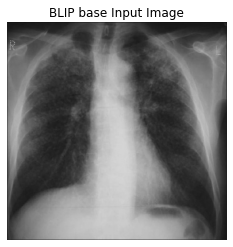

BLIP base Caption (Chest X-rays): a medical scan of the chest


In [3]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_00154.jpg"
image = Image.open(image_path).convert("RGB")
# chest X-rays images:, ROCO_00074, ROCO_00154, ROCO_00172, ROCO_00222, ROCO_00230, ROCO_00238, ROCO_00272

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP base Input Image")
plt.savefig("type1_chest_xray.jpg")
plt.show()

# === Generate Caption ===
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(model.device)

out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)
print("BLIP base Caption (Chest X-rays):", caption)

### 2. Brain MRI/CT:

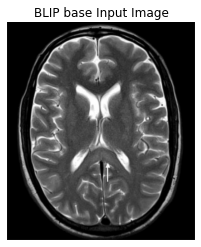

BLIP base Caption (Brain MRI/CT): a medical scan of the brain


In [4]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_00710.jpg"
image = Image.open(image_path).convert("RGB")
# brain images:ROCO_00681, ROCO_00710, ROCO_00819, ROCO_00848, ROCO_01034, ROCO_01020

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP base Input Image")
plt.savefig("type2_brain_mri.jpg")
plt.show()

# === Generate Caption ===
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(model.device)

out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)
print("BLIP base Caption (Brain MRI/CT):", caption)

### 3. Knee/Joint MRI/X-rays

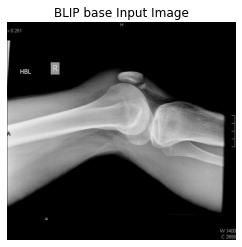

BLIP base Caption (Knee/Joint MRI/X-rays): a medical scan showing the fracture of the left knee


In [5]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_02161.jpg"
image = Image.open(image_path).convert("RGB")
# knee/joint images: ROCO_01044, ROCO_02161, ROCO_03443, ROCO_06844, ROCO_03012, ROCO_07943

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP base Input Image")
plt.savefig("type3_knee_xray.jpg")
plt.show()

# === Generate Caption ===
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(model.device)

out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)
print("BLIP base Caption (Knee/Joint MRI/X-rays):", caption)

### 4. Abdomen CT/UltraSound

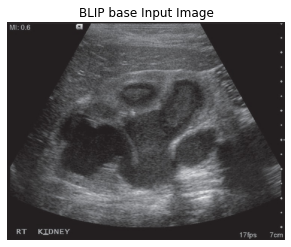

BLIP base Caption (Abdomen CT/Ultrasound): a medical scan with a small, flat, black, and white area


In [6]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_38012.jpg"
image = Image.open(image_path).convert("RGB")
# abdomen 1: ROCO_35536, ROCO_00015, ROCO_35687, ROCO_36300, ROCO_36416, ROCO_36721
# abdomen 2: ROCO_37251,ROCO_38012, ROCO_39045, ROCO_39184 , ROCO_39328

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP base Input Image")
plt.savefig("type4_abdomen_ultrasound.jpg")
plt.show()

# === Generate Caption ===
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(model.device)

out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)
print("BLIP base Caption (Abdomen CT/Ultrasound):", caption)

### 5. Spine/Back MRI

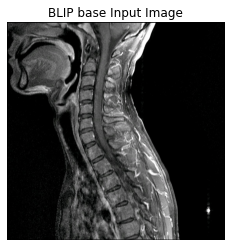

BLIP base Caption (Spine/Back MRI): a medical scan with a radiograph of the cervical bone


In [7]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_44556.jpg"
image = Image.open(image_path).convert("RGB")
# spine/back: ROCO_39818, ROCO_40628, ROCO_40466, ROCO_41475, ROCO_44556, ROCO_45173, ROCO_47829

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP base Input Image")
plt.savefig("type5_Spine_MRI.jpg")
plt.show()

# === Generate Caption ===
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(model.device)

out = model.generate(**inputs)
caption = processor.decode(out[0], skip_special_tokens=True)
print("BLIP base Caption (Spine/Back MRI):", caption)

## BLIP base -> Attention Visualization

Caption: a chest x - ray with a large, open chest


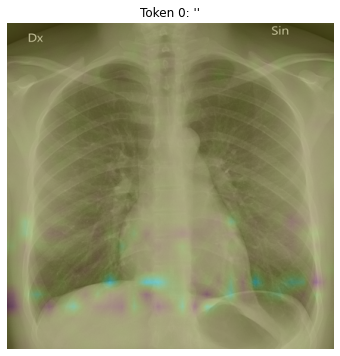

In [22]:
import torch
import torch.nn.functional as F
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# === Load model and processor ===
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device).eval()

# === Load image ===
# image_path = "roco-dataset-master/data/train/radiology/images/ROCO_44556.jpg"
image_path = "/scratch/klimbu2/Final_Project/test.jpg"
raw_image = Image.open(image_path).convert("RGB")
image_tensor = processor(images=raw_image, return_tensors="pt")["pixel_values"][0]
H, W = raw_image.size

# === Hook for attention maps ===
attention_maps = []

def save_attention_hook(module, input, output):
    attention_maps.append(output)

# Register hook to decoder cross-attention
for block in model.text_decoder.bert.encoder.layer:
    block.crossattention.self.register_forward_hook(save_attention_hook)

# === Generate caption ===
inputs = processor(images=raw_image, return_tensors="pt").to(device)
attention_maps.clear()
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=20)

# === Decode caption ===
caption = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
tokens = processor.tokenizer.convert_ids_to_tokens(output_ids[0])
print("Caption:", caption)

# === Generate Caption ===
# text_prompt = "a medical scan"  # you can also set this to None
# inputs = processor(image, text_prompt, return_tensors="pt").to(model.device)

# out = model.generate(**inputs)
# caption = processor.decode(out[0], skip_special_tokens=True)
# print("BLIP base Caption (Spine/Back MRI):", caption)

# === Process and visualize attention maps ===
if not attention_maps:
    print("No attention maps were captured.")
else:
    # Get last layer attention: [1, heads, tgt_len, src_len]
    attn_tensor = attention_maps[-1][0]  # shape: [heads, tgt_len, src_len]
    attn_avg = attn_tensor.mean(dim=0)   # average over heads → [tgt_len, src_len]

    num_tokens = attn_avg.shape[0]
    num_patches = attn_avg.shape[1] - 1  # Exclude CLS token
    patch_size = int(np.sqrt(num_patches))
    image_np = np.array(raw_image.resize((patch_size*16, patch_size*16)))  # upscale to fit patch grid

    for i in range(num_tokens):
        token_id = output_ids[0][i].item()
        token_str = processor.tokenizer.decode(token_id)
        if token_str in ["<pad>", "</s>"]:
            continue
            
        weights = attn_avg[i, 1:]  # Drop CLS token
        weights = F.softmax(weights, dim=0).cpu().numpy()
        weights = (weights - weights.min()) / (weights.max() - weights.min())

        try:
            attn_map = weights[:patch_size * patch_size].reshape(patch_size, patch_size)
            attn_map = cv2.resize(attn_map, (image_np.shape[1], image_np.shape[0]))
            attn_map = np.uint8(255 * attn_map)
            attn_color = cv2.applyColorMap(attn_map, cv2.COLORMAP_VIRIDIS)
            overlay = cv2.addWeighted(image_np, 0.6, attn_color, 0.4, 0)

            plt.figure(figsize=(6, 6))
            plt.imshow(overlay)
            plt.title(f"Token {i}: '{token_str}'")
            plt.axis("off")
            # plt.savefig("attention.jpg")
            plt.savefig(f"attention_base_{i}_{token_str.strip().replace('/', '_')}.jpg")

            plt.show()
        except Exception as e:
            print(f"Token {i} skipped due to error: {e}")


# BLIP Baseline Evaluation

In [23]:
import os
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Allows PIL to load broken images

# --- Load ground truth captions from .txt file ---
def load_roco_captions(txt_path):
    gt = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                image_id, caption = parts
                if caption.strip():  # Ensure caption isn't empty
                    gt[image_id + ".jpg"] = caption.strip()
    return gt

# Paths
# image_path = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/images/ROCO_00012.jpg"
# image = Image.open(image_path).convert("RGB")
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# Load captions
gt_captions = load_roco_captions(captions_txt_path)
image_list = [
    fname for fname in gt_captions.keys()
    if os.path.exists(os.path.join(image_dir, fname))
]

In [24]:
from transformers import BlipProcessor, BlipForConditionalGeneration
import torch
from tqdm import tqdm
import json


# === Load model from snapshot ===
model_path = "/scratch/klimbu2/huggingface/transformers/models--Salesforce--blip-image-captioning-base/snapshots/82a37760796d32b1411fe092ab5d4e227313294b"


processor = BlipProcessor.from_pretrained(model_path)
model = BlipForConditionalGeneration.from_pretrained(model_path).to("cuda" if torch.cuda.is_available() else "cpu")

# Store generated and reference captions
generated = {}
references = {}

# Generate captions
for fname in tqdm(image_list):
    try:
        img_path = os.path.join(image_dir, fname)
        image = Image.open(img_path).convert("RGB")

        inputs = processor(image, "a medical scan", return_tensors="pt").to(model.device)
        output = model.generate(**inputs)
        caption = processor.decode(output[0], skip_special_tokens=True)

        generated[fname] = [caption]
        references[fname] = [gt_captions[fname]]
        print(fname)
        print(caption)

    except Exception as e:
        print(f"Error processing {fname}: {e}")
        

# Save dictionaries to JSON files
with open("generated_captions.json", "w") as gen_f:
    json.dump(generated, gen_f)

with open("reference_captions.json", "w") as ref_f:
    json.dump(references, ref_f)

  0%|          | 2/8176 [00:00<24:27,  5.57it/s]

ROCO_00001.jpg
a medical scan shows the brain and the radiology of a patient
ROCO_00006.jpg
a medical scan with a small, black and white image of the chest


  0%|          | 4/8176 [00:00<17:20,  7.85it/s]

ROCO_00016.jpg
a medical scan of the brain
ROCO_00025.jpg
a medical scan of the knee


  0%|          | 6/8176 [00:00<16:53,  8.06it/s]

...

 12%|█▏        | 974/8176 [02:19<17:14,  6.96it/s]

ROCO_09885.jpg
a medical scan of the brain
ROCO_09888.jpg
a medical scan of the left side of the brain


 12%|█▏        | 975/8176 [02:20<17:15,  6.96it/s]

ROCO_09917.jpg
a medical scan of the abdomen shows a cross in the middle of the abdomen


KeyboardInterrupt: 

In [18]:
import json
with open("generated_captions.json", "r") as gen_f:
    generated = json.load(gen_f)

with open("reference_captions.json", "r") as ref_f:
    references = json.load(ref_f)

In [19]:
!pip install bert_score

Defaulting to user installation because normal site-packages is not writeable


In [22]:
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
from numpy import ndarray
from tqdm import tqdm
from bert_score import score

# === Bio_ClinicalBERT setup ===
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# === Sentence embedding function (mean-pooled) ===
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden = outputs.last_hidden_state
    mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
    masked = last_hidden * mask
    summed = masked.sum(1)
    counts = mask.sum(1)
    mean_pooled = summed / counts
    return mean_pooled.squeeze().cpu().numpy()

# Flatten generated and reference captions to lists
preds = [generated[k][0] for k in image_list]
refs = [references[k][0] for k in image_list]

# === Cosine similarity using Bio_ClinicalBERT mean-pooling ===
similarities = []
for pred, ref in tqdm(zip(preds, refs), total=len(preds), desc="Bio_ClinicalBERT Cosine"):
    try:
        emb_pred = get_embedding(pred)
        emb_ref = get_embedding(ref)
        if isinstance(emb_pred, ndarray) and isinstance(emb_ref, ndarray) and emb_pred.shape == emb_ref.shape:
            sim = cosine_similarity([emb_pred], [emb_ref])[0][0]
        else:
            sim = 0.0
        similarities.append(sim)
    except Exception as e:
        print(f"Error comparing: {e}")
        similarities.append(0.0)

bio_clinical_cosine = sum(similarities) / len(similarities)

# === Official BERTScore with Bio_ClinicalBERT model ===
def truncate_to_512(texts, tokenizer):
    truncated = []
    for t in texts:
        tokens = tokenizer.tokenize(t)
        tokens = tokens[:510]  # Leave room for [CLS] and [SEP]
        truncated_text = tokenizer.convert_tokens_to_string(tokens)
        truncated.append(truncated_text)
    return truncated

# Apply truncation
preds_trunc = truncate_to_512(preds, tokenizer)
refs_trunc = truncate_to_512(refs, tokenizer)

# Then pass to BERTScore
P_BERTScore_Bio_ClinicalBERT, R_BERTScore_Bio_ClinicalBERT, F1_BERTScore_Bio_ClinicalBERT = score(
    preds_trunc, refs_trunc,
    model_type=model_name,
    num_layers=12,
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# === Official BERTScore using BERT-base ===
P_Original_BERT, R_Original_BERT, F1_Original_BERT = score(
    preds, refs,
    model_type="bert-base-uncased",
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# === Print all scores ===
print(f"\n--- Evaluation Summary ---")
print(f"Bio_ClinicalBERT Cosine Similarity (Mean Pooled): {bio_clinical_cosine:.4f}")
print(f"BERTScore with Bio_ClinicalBERT:\n"
      f"\tPrecision: {P_BERTScore_Bio_ClinicalBERT.mean():.4f}\n"
      f"\tRecall:    {R_BERTScore_Bio_ClinicalBERT.mean():.4f}\n"
      f"\tF1-Score:  {F1_BERTScore_Bio_ClinicalBERT.mean():.4f}")
print(f"Original BERTScore:\n"
      f"\tPrecision: {P_Original_BERT.mean():.4f}\n"
      f"\tRecall:    {R_Original_BERT.mean():.4f}\n"
      f"\tF1-Score:  {F1_Original_BERT.mean():.4f}")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]


Bio_ClinicalBERT Cosine: 100%|██████████| 8176/8176 [01:59<00:00, 68.36it/s]


...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]


--- Evaluation Summary ---
Bio_ClinicalBERT Cosine Similarity (Mean Pooled): 0.8498
BERTScore with Bio_ClinicalBERT:
	Precision: 0.7438
	Recall:    0.6763
	F1-Score:  0.7078
Original BERTScore:
	Precision: 0.5054
	Recall:    0.4122
	F1-Score:  0.4518


In [26]:
!pip install pycocoevalcap

Defaulting to user installation because normal site-packages is not writeable


In [27]:
import os
import sys
import json
import torch
import logging
import warnings
import tempfile
import contextlib
from tqdm import tqdm
from numpy import ndarray
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from bert_score import score
# === COCOEvalCap (CIDEr & SPICE only) ===
from pycocoevalcap.eval import COCOEvalCap
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocotools.coco import COCO
import io

# Suppress warnings & transformers logs
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# === Bio_ClinicalBERT Setup ===
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# === Sentence Embedding Function (mean-pooled) ===
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden = outputs.last_hidden_state
    mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
    masked = last_hidden * mask
    summed = masked.sum(1)
    counts = mask.sum(1)
    mean_pooled = summed / counts
    return mean_pooled.squeeze().cpu().numpy()

# === Inputs: preds, refs ===
# Replace with your actual values
preds = [generated[k][0] for k in image_list]
refs = [references[k][0] for k in image_list]

# === Cosine Similarity (Mean-Pooled Bio_ClinicalBERT) ===
similarities = []
for pred, ref in tqdm(zip(preds, refs), total=len(preds), desc="Bio_ClinicalBERT Cosine"):
    try:
        emb_pred = get_embedding(pred)
        emb_ref = get_embedding(ref)
        if isinstance(emb_pred, ndarray) and isinstance(emb_ref, ndarray) and emb_pred.shape == emb_ref.shape:
            sim = cosine_similarity([emb_pred], [emb_ref])[0][0]
        else:
            sim = 0.0
    except:
        sim = 0.0
    similarities.append(sim)
bio_clinical_cosine = sum(similarities) / len(similarities)

# === BERTScore (Bio_ClinicalBERT & Original) ===
def truncate_to_512(texts, tokenizer):
    return [tokenizer.convert_tokens_to_string(tokenizer.tokenize(t)[:510]) for t in texts]

preds_trunc = truncate_to_512(preds, tokenizer)
refs_trunc = truncate_to_512(refs, tokenizer)

P_Bio, R_Bio, F1_Bio = score(
    preds_trunc, refs_trunc,
    model_type=model_name,
    num_layers=12,
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

P_BERT, R_BERT, F1_BERT = score(
    preds, refs,
    model_type="bert-base-uncased",
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

pred_dict = {str(i): [pred] for i, pred in enumerate(preds)}
ref_dict  = {str(i): [ref] for i, ref in enumerate(refs)}

def prepare_coco_format(pred_dict, ref_dict):
    ann = {'annotations': [], 'images': [], 'type': 'captions', 'info': {}, 'licenses': []}
    for image_id in ref_dict:
        ann['images'].append({'id': image_id})
        for idx, caption in enumerate(ref_dict[image_id]):
            ann['annotations'].append({
                'image_id': image_id,
                'id': int(f"{image_id}{idx}"),
                'caption': caption
            })
    return ann, [{'image_id': k, 'caption': v[0]} for k, v in pred_dict.items()]

ann_file, res_file = tempfile.NamedTemporaryFile(delete=False), tempfile.NamedTemporaryFile(delete=False)
with open(ann_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[0], f)
with open(res_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[1], f)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    coco = COCO(ann_file.name)
    cocoRes = coco.loadRes(res_file.name)
    
tokenizer = PTBTokenizer()
coco.evalImgs = []
cocoEval = COCOEvalCap(coco, cocoRes)
cocoEval.params['eval'] = ['CIDEr', 'SPICE']

# === Suppress COCOEvalCap stdout/stderr ===
@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

with suppress_stdout_stderr():
    cocoEval.evaluate()

# === Final Clean Output ===
print(f"\n--- Evaluation Summary for Fine-Tuned BERT Model ---")
print(f"Bio_ClinicalBERT Cosine Similarity (Mean Pooled): {bio_clinical_cosine:.4f}")
print(f"BERTScore with Bio_ClinicalBERT:\n"
      f"\tPrecision: {P_Bio.mean():.4f}\n"
      f"\tRecall:    {R_Bio.mean():.4f}\n"
      f"\tF1-Score:  {F1_Bio.mean():.4f}")
print(f"Original BERTScore:\n"
      f"\tPrecision: {P_BERT.mean():.4f}\n"
      f"\tRecall:    {R_BERT.mean():.4f}\n"
      f"\tF1-Score:  {F1_BERT.mean():.4f}")
print(f"CIDEr: {cocoEval.eval['CIDEr']:.4f}")
print(f"SPICE: {cocoEval.eval['SPICE']:.4f}")

# === Cleanup
os.unlink(ann_file.name)
os.unlink(res_file.name)

Bio_ClinicalBERT Cosine: 100%|██████████| 8176/8176 [01:58<00:00, 68.94it/s]
May 03, 2025 7:39:12 PM edu.stanford.nlp.process.PTBLexer next
PTBTokenizer tokenized 200345 tokens at 1217791.99 tokens per second.
PTBTokenizer tokenized 91728 tokens at 937651.51 tokens per second.
Parsing reference captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.4 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pipel

SPICE evaluation took: 2.271 min

--- Evaluation Summary for Fine-Tuned BERT Model ---
Bio_ClinicalBERT Cosine Similarity (Mean Pooled): 0.8498
BERTScore with Bio_ClinicalBERT:
	Precision: 0.7438
	Recall:    0.6763
	F1-Score:  0.7078
Original BERTScore:
	Precision: 0.5054
	Recall:    0.4122
	F1-Score:  0.4518
CIDEr: 0.0294
SPICE: 0.0171


# BLIP Fine-Tuning Model

In [28]:
!pip install transformers datasets timm evaluate accelerate bitsandbytes

Defaulting to user installation because normal site-packages is not writeable


## Pre-Processing Model

In [39]:
import os
import pandas as pd
from datasets import Dataset
import re

data = []
cap_dir = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/captions.txt"
with open(cap_dir, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        match = re.match(r"^(ROCO_\d+)[\s\u2192]*\s+(.*)$", line)  # handles arrow and whitespace
        if match:
            image_id, caption = match.groups()
            data.append({"image_id": image_id + ".jpg", "caption": caption})

df = pd.DataFrame(data)

# Optional: filter to images that exist
image_dir = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/images"
available_images = set(os.listdir(image_dir))
df = df[df["image_id"].isin(available_images)]

# Reset index
df = df.reset_index(drop=True)
print(df.head())

# Convert to HuggingFace dataset
dataset = Dataset.from_pandas(df)

dataset.shape

         image_id                                            caption
0  ROCO_00002.jpg  Computed tomography scan in axial view showing...
1  ROCO_00003.jpg  Bacterial contamination occurred after complet...
2  ROCO_00004.jpg  The patient had residual paralysis of the hand...
3  ROCO_00005.jpg      Panoramic radiograph after immediate loading.
4  ROCO_00007.jpg  Plain abdomen x-ray: Multiple air levels at th...


(65419, 2)

In [45]:
from PIL import Image, ImageFile
from transformers import BlipProcessor
from datasets import Dataset, concatenate_datasets
import os
import torch

# Allow PIL to load truncated images silently
ImageFile.LOAD_TRUNCATED_IMAGES = True

# === Config ===
# image_dir = "roco-dataset-master/data/train/radiology/images"
image_dir = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/images"
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
batch_size = 32
chunk_size = 9500
output_dir = "processed_roco_chunks"
os.makedirs(output_dir, exist_ok=True)

# === Preprocessing Function ===
# def preprocess_batch(batch):
#     images, captions = [], []

#     for image_id, caption in zip(batch["image_id"], batch["caption"]):
#         try:
#             image_path = os.path.join(image_dir, image_id)
#             image = Image.open(image_path).convert("RGB")
#             images.append(image)
#             captions.append(caption)
#         except:
#             continue  # silently skip corrupted

#     if not images:
#         return {"input_ids": [], "attention_mask": [], "pixel_values": []}

#     inputs = processor(
#         images=images,
#         text=captions,
#         padding="max_length",
#         max_length=128,
#         truncation=True,
#         return_tensors="pt"
#     )

#     return {
#         "input_ids": list(inputs["input_ids"]),
#         "attention_mask": list(inputs["attention_mask"]),
#         "pixel_values": list(inputs["pixel_values"])
#     }

def preprocess_batch(batch):
    images, captions = [], []

    for image_id, caption in zip(batch["image_id"], batch["caption"]):
        try:
            image_path = os.path.join(image_dir, image_id)
            image = Image.open(image_path).convert("RGB")
            images.append(image)
            captions.append(caption)
        except Exception as e:
            print(f"Failed to load {image_id}: {e}")  # add this for debugging
            continue

    if not images:
        print("Skipping batch: No valid images found.")  # add this for debugging
        return {"input_ids": [], "attention_mask": [], "pixel_values": []}

    inputs = processor(
        images=images,
        text=captions,
        padding="max_length",
        max_length=128,
        truncation=True,
        return_tensors="pt"
    )

    return {
        "input_ids": list(inputs["input_ids"]),
        "attention_mask": list(inputs["attention_mask"]),
        "pixel_values": list(inputs["pixel_values"])
    }


# === Streaming + Chunking with Resume ===
partial_datasets = []
total = len(dataset)
for i in range(0, total, chunk_size):
    chunk_idx = i // chunk_size
    save_path = os.path.join(output_dir, f"chunk_{chunk_idx}")

    if os.path.exists(save_path):
        print(f"Chunk {chunk_idx} already processed. Skipping...")
        partial_datasets.append(save_path)
        continue

    print(f"\n>>> Processing chunk {i} to {i + chunk_size}...")
    chunk = dataset.select(range(i, min(i + chunk_size, total)))

    processed = chunk.map(
        preprocess_batch,
        batched=True,
        batch_size=batch_size,
        remove_columns=chunk.column_names,
        desc=f"Processing {i}-{i+chunk_size}"
    )

    # processed.save_to_disk(save_path)
    # partial_datasets.append(save_path)
    if len(processed) == 0:
        print(f"Chunk {chunk_idx} has no valid data. Skipping...")
        continue  # 🔁 ADD this check

    processed.save_to_disk(save_path)
    partial_datasets.append(save_path)


# === Final: Merge All Chunks
# final_dataset = concatenate_datasets([Dataset.load_from_disk(p) for p in partial_datasets])
# print(f"\nFinal dataset size: {len(final_dataset)}")

from datasets import load_from_disk, concatenate_datasets

# Find all valid chunk directories
valid_chunk_paths = [
    os.path.join(output_dir, d)
    for d in os.listdir(output_dir)
    if os.path.isdir(os.path.join(output_dir, d)) and d.startswith("chunk_")
]

# Safely load non-empty datasets
valid_datasets = []
for path in valid_chunk_paths:
    try:
        ds = load_from_disk(path)
        if len(ds) > 0:
            valid_datasets.append(ds)
    except Exception as e:
        print(f"Skipping {path}, load failed: {e}")

# Concatenate if any valid chunks exist
if valid_datasets:
    final_dataset = concatenate_datasets(valid_datasets)
    print(f"\nFinal dataset size: {len(final_dataset)}")
    final_dataset.save_to_disk("processed_roco_final")
else:
    print("No valid preprocessed chunks found.")



>>> Processing chunk 0 to 9500...


Processing 0-9500:   0%|          | 0/9500 [00:00<?, ? examples/s]

Saving the dataset (0/34 shards):   0%|          | 0/9500 [00:00<?, ? examples/s]


>>> Processing chunk 9500 to 19000...


Processing 9500-19000:   0%|          | 0/9500 [00:00<?, ? examples/s]

...

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/30 [00:00<?, ?it/s]


✅ Final dataset size: 65419


Saving the dataset (0/233 shards):   0%|          | 0/65419 [00:00<?, ? examples/s]

In [46]:
from datasets import Dataset, concatenate_datasets, load_from_disk
import os

# Path where all chunks are saved
output_dir = "processed_roco_chunks"

# Get all chunk paths (sorted to maintain order)
chunk_paths = sorted([
    os.path.join(output_dir, d)
    for d in os.listdir(output_dir)
    if os.path.isdir(os.path.join(output_dir, d)) and d.startswith("chunk_")
])

# Load and concatenate all chunks
final_dataset = concatenate_datasets([load_from_disk(path) for path in chunk_paths])
print(f"Final dataset size: {len(final_dataset)}")
final_dataset.save_to_disk("processed_roco_final")

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/34 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/30 [00:00<?, ?it/s]

Final dataset size: 65419


Saving the dataset (0/233 shards):   0%|          | 0/65419 [00:00<?, ? examples/s]

## Training BLIP Fine-Tuned Model

In [47]:
from datasets import load_from_disk
from torch.utils.data import DataLoader
from transformers import default_data_collator

# === Config ===
DATA_PATH = "processed_roco_final"
BATCH_SIZE = 8  # Tune as per your GPU

# === Load preprocessed HuggingFace Dataset ===
dataset = load_from_disk(DATA_PATH)

# === Create DataLoader with proper collate_fn ===
train_dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=default_data_collator  # FIX: Ensures batch is a dictionary
)

print(f"Dataloader initialized with {len(train_dataloader)} batches.")
print(dataset[0].keys())  # Should show: input_ids, attention_mask, pixel_values

Loading dataset from disk:   0%|          | 0/233 [00:00<?, ?it/s]

Dataloader initialized with 8178 batches.
dict_keys(['input_ids', 'attention_mask', 'pixel_values'])


In [50]:
import torch
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
# from torch.amp import autocast, GradScaler  # Use torch.amp instead of torch.cuda.amp
from torch.cuda.amp import autocast, GradScaler

from transformers import BlipForConditionalGeneration, get_scheduler
from tqdm import tqdm
from torch.utils.data import DataLoader
from datasets import load_from_disk
from transformers import default_data_collator

# === Config ===
DATA_PATH = "processed_roco_final"
BATCH_SIZE = 8
GRAD_ACCUM = 4
EPOCHS = 1  # Start with 1 for stability, increase later if needed
LEARNING_RATE = 5e-5
MODEL_SAVE_PATH = "blip-finetuned-roco"

# === Load dataset ===
dataset = load_from_disk(DATA_PATH)
train_dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=default_data_collator
)

# === Model, Device, Optimizer, Scheduler ===
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
num_training_steps = len(train_dataloader) * EPOCHS // GRAD_ACCUM
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

scaler = GradScaler()  # Updated for deprecation fix

# === Training Loop ===
model.train()
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    progress_bar = tqdm(enumerate(train_dataloader), total=len(train_dataloader))

    for step, batch in progress_bar:
        try:
            batch = {k: v.to(device) for k, v in batch.items()}

            #with autocast(device_type="cuda"):  # Updated for deprecation fix
            with autocast():  # <-- FIXED LINE
                outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    pixel_values=batch["pixel_values"],
                    labels=batch["input_ids"]
                )
                loss = outputs.loss / GRAD_ACCUM

            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_dataloader):
                clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                lr_scheduler.step()

            progress_bar.set_description(f"Epoch {epoch+1}")
            progress_bar.set_postfix(loss=round(loss.item() * GRAD_ACCUM, 4))

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print("Skipping batch due to OOM")
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
            else:
                raise e

# === Save Fine-tuned Model ===
model.save_pretrained(MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")

Loading dataset from disk:   0%|          | 0/233 [00:00<?, ?it/s]


--- Epoch 1/1 ---


Epoch 1: 100%|██████████| 8178/8178 [5:14:57<00:00,  2.31s/it, loss=0.724]] 



Model saved to: blip-finetuned-roco


In [230]:
from transformers import BlipProcessor

# Load original processor
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

# Save to same folder where model is saved
processor.save_pretrained("blip-finetuned-roco")

[]

##  BLIP base vs BLIP Fine-tuned -> Caption Generation: 

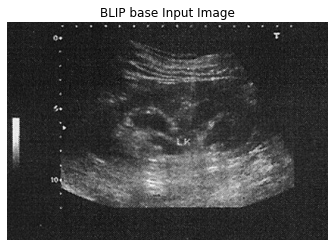

Generated Caption BLIP base Model (baseline model): a medical scan of a patient ' s breast
Generated Caption BLIP Fine-tuned Model: ultrasound image of the left kidney.


In [231]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import torch
import matplotlib.pyplot as plt
# import os

# Load model and processor
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
baseline_blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to("cuda" if torch.cuda.is_available() else "cpu")
fine_tuned_model = BlipForConditionalGeneration.from_pretrained("blip-finetuned-roco").to("cuda" if torch.cuda.is_available() else "cpu")

# === Load image ===
# image = Image.open("roco-dataset/data/test/radiology/images/ROCO_00218.jpg").convert("RGB")
image_path = "/scratch/klimbu2/Final_Project/roco-dataset-master/data/train/radiology/images/ROCO_00015.jpg"
image = Image.open(image_path).convert("RGB")

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP base Input Image")
plt.show()

# Generate Baseline Caption
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(baseline_blip_model.device)
out_baseline = baseline_blip_model.generate(**inputs)
caption_baseline = processor.decode(out_baseline[0], skip_special_tokens=True)
print("Generated Caption BLIP base Model (baseline model):", caption_baseline)

# Preprocess and Generate Fine-Tuned Caption
fine_tuned_model.eval()
inputs = processor(images=image, return_tensors="pt").to(fine_tuned_model.device)
out_fine_tuned = fine_tuned_model.generate(**inputs)
caption_fine_tuned = processor.decode(out_fine_tuned[0], skip_special_tokens=True)
print("Generated Caption BLIP Fine-tuned Model:", caption_fine_tuned)

##  BLIP base vs BLIP Fine-tuned -> Comparision (for Different Image Types)

### 1. Chest X-rays:

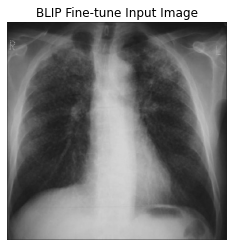

BLIP base Caption(Chest X-ray): a medical scan of the chest
BLIP Fine-tuned Caption(Chest X-ray): chest x - ray showing bilateral pleural effusion


In [243]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_00154.jpg"
image = Image.open(image_path).convert("RGB")
# chest X-rays images:, ROCO_00074, ROCO_00154, ROCO_00172, ROCO_00222, ROCO_00230, ROCO_00238, ROCO_00272

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP Fine-tune Input Image")
plt.show()

# Generate Baseline Caption
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(baseline_blip_model.device)
out_baseline = baseline_blip_model.generate(**inputs)
caption_baseline = processor.decode(out_baseline[0], skip_special_tokens=True)
print("BLIP base Caption(Chest X-ray):", caption_baseline)

# Preprocess and Generate Fine-Tuned Caption
fine_tuned_model.eval()
inputs = processor(images=image, return_tensors="pt").to(fine_tuned_model.device)
out_fine_tuned = fine_tuned_model.generate(**inputs)
caption_fine_tuned = processor.decode(out_fine_tuned[0], skip_special_tokens=True)
print("BLIP Fine-tuned Caption(Chest X-ray):", caption_fine_tuned)

### 2. Brain MRI/CT:

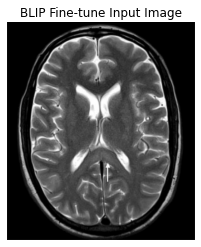

BLIP base Caption(Brain MRI/CT): a medical scan of the brain
BLIP Fine-tuned Caption(Brain MRI/CT): mri brain showing a hyperintense lesion in the left frontal lobe ( arrow ).


In [244]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_00710.jpg"
image = Image.open(image_path).convert("RGB")
# brain images:ROCO_00681, ROCO_00710, ROCO_00819, ROCO_00848, ROCO_01034, ROCO_01020

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP Fine-tune Input Image")
plt.show()

# Generate Baseline Caption
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(baseline_blip_model.device)
out_baseline = baseline_blip_model.generate(**inputs)
caption_baseline = processor.decode(out_baseline[0], skip_special_tokens=True)
print("BLIP base Caption(Brain MRI/CT):", caption_baseline)

# Preprocess and Generate Fine-Tuned Caption
fine_tuned_model.eval()
inputs = processor(images=image, return_tensors="pt").to(fine_tuned_model.device)
out_fine_tuned = fine_tuned_model.generate(**inputs)
caption_fine_tuned = processor.decode(out_fine_tuned[0], skip_special_tokens=True)
print("BLIP Fine-tuned Caption(Brain MRI/CT):", caption_fine_tuned)

### 3. Knee/Joint MRI/X-rays

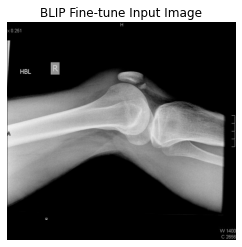

BLIP base Caption(Knee/Joint MRI/X-rays): a medical scan showing the fracture of the left knee
BLIP Fine-tuned Caption(Knee/Joint MRI/X-rays): radiograph of the right knee showing a large osteolytic lesion in the proximal


In [245]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_02161.jpg"
image = Image.open(image_path).convert("RGB")
# knee/joint images: ROCO_01044, ROCO_02161, ROCO_03443, ROCO_06844, ROCO_03012, ROCO_07943

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP Fine-tune Input Image")
plt.show()

# Generate Baseline Caption
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(baseline_blip_model.device)
out_baseline = baseline_blip_model.generate(**inputs)
caption_baseline = processor.decode(out_baseline[0], skip_special_tokens=True)
print("BLIP base Caption(Knee/Joint MRI/X-rays):", caption_baseline)

# Preprocess and Generate Fine-Tuned Caption
fine_tuned_model.eval()
inputs = processor(images=image, return_tensors="pt").to(fine_tuned_model.device)
out_fine_tuned = fine_tuned_model.generate(**inputs)
caption_fine_tuned = processor.decode(out_fine_tuned[0], skip_special_tokens=True)
print("BLIP Fine-tuned Caption(Knee/Joint MRI/X-rays):", caption_fine_tuned)

### 4. Abdomen CT/UltraSound

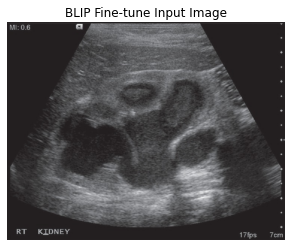

BLIP base Caption(Abodomen CT/UltraSound): a medical scan with a small, flat, black, and white area
BLIP Fine-tuned Caption(Abodomen CT/UltraSound): ultrasound image of the right kidney.


In [246]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_38012.jpg"
image = Image.open(image_path).convert("RGB")
# abdomen 1: ROCO_35536, ROCO_00015, ROCO_35687, ROCO_36300, ROCO_36416, ROCO_36721
# abdomen 2: ROCO_37251,ROCO_38012, ROCO_39045, ROCO_39184 , ROCO_39328

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP Fine-tune Input Image")
plt.show()

# Generate Baseline Caption
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(baseline_blip_model.device)
out_baseline = baseline_blip_model.generate(**inputs)
caption_baseline = processor.decode(out_baseline[0], skip_special_tokens=True)
print("BLIP base Caption(Abodomen CT/UltraSound):", caption_baseline)

# Preprocess and Generate Fine-Tuned Caption
fine_tuned_model.eval()
inputs = processor(images=image, return_tensors="pt").to(fine_tuned_model.device)
out_fine_tuned = fine_tuned_model.generate(**inputs)
caption_fine_tuned = processor.decode(out_fine_tuned[0], skip_special_tokens=True)
print("BLIP Fine-tuned Caption(Abodomen CT/UltraSound):", caption_fine_tuned)

### 5. Spine/Back MRI

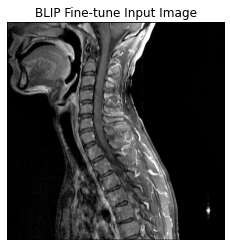

BLIP base Caption(Spine/Back MRI): a medical scan with a radiograph of the cervical bone
BLIP Fine-tuned Caption(Spine/Back MRI): sagittal t2 - weighted magnetic resonance imaging of the cervical spine showing a large mass in the


In [247]:
# === Load image ===
image_path = "roco-dataset-master/data/train/radiology/images/ROCO_44556.jpg"
image = Image.open(image_path).convert("RGB")
# spine/back: ROCO_39818, ROCO_40628, ROCO_40466, ROCO_41475, ROCO_44556, ROCO_45173, ROCO_47829

# === Optional: View the image ===
plt.imshow(image)
plt.axis("off")
plt.title("BLIP Fine-tune Input Image")
plt.show()

# Generate Baseline Caption
text_prompt = "a medical scan"  # you can also set this to None
inputs = processor(image, text_prompt, return_tensors="pt").to(baseline_blip_model.device)
out_baseline = baseline_blip_model.generate(**inputs)
caption_baseline = processor.decode(out_baseline[0], skip_special_tokens=True)
print("BLIP base Caption(Spine/Back MRI):", caption_baseline)

# Preprocess and Generate Fine-Tuned Caption
fine_tuned_model.eval()
inputs = processor(images=image, return_tensors="pt").to(fine_tuned_model.device)
out_fine_tuned = fine_tuned_model.generate(**inputs)
caption_fine_tuned = processor.decode(out_fine_tuned[0], skip_special_tokens=True)
print("BLIP Fine-tuned Caption(Spine/Back MRI):", caption_fine_tuned)

# BLIP Fine-Tuned Evaluation

In [3]:
import os
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Allows PIL to load broken images

# --- Load ground truth captions from .txt file ---
def load_roco_captions(txt_path):
    gt = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                image_id, caption = parts
                if caption.strip():  # Ensure caption isn't empty
                    gt[image_id + ".jpg"] = caption.strip()
    return gt

# Paths
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# Load captions
gt_captions = load_roco_captions(captions_txt_path)
image_list = [
    fname for fname in gt_captions.keys()
    if os.path.exists(os.path.join(image_dir, fname))
]

In [4]:
import os
import json
from PIL import Image, ImageFile
from tqdm import tqdm
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

ImageFile.LOAD_TRUNCATED_IMAGES = True

# === Paths ===
model_path = "blip-finetuned-roco"
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# === Load processor and model ===
processor = BlipProcessor.from_pretrained(model_path)
model = BlipForConditionalGeneration.from_pretrained(model_path).to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# === Load test image-caption pairs ===
def load_roco_captions(txt_path):
    gt = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                image_id, caption = parts
                if caption.strip():
                    gt[image_id + ".jpg"] = caption.strip()
    return gt

gt_captions = load_roco_captions(captions_txt_path)
image_list = [
    fname for fname in gt_captions.keys()
    if os.path.exists(os.path.join(image_dir, fname))
]

# === Generate captions ===
generated = {}
for fname in tqdm(image_list, desc="Generating captions"):
    try:
        image = Image.open(os.path.join(image_dir, fname)).convert("RGB")
        inputs = processor(image, "a medical scan", return_tensors="pt").to(model.device)
        output = model.generate(**inputs)
        caption = processor.decode(output[0], skip_special_tokens=True)
        generated[fname] = [caption]
    except Exception as e:
        print(f"Skipping {fname}: {e}")

# === Save output ===
with open("generated_finetuned_captions.json", "w") as f:
    json.dump(generated, f)

print("Captions generated and saved to generated_finetuned_captions.json")

Generating captions: 100%|██████████| 8176/8176 [30:11<00:00,  4.51it/s]

Captions generated and saved to generated_finetuned_captions.json


In [5]:
import json

with open("generated_finetuned_captions.json", "r") as gen_f:
    generated_finetuned = json.load(gen_f)

with open("reference_captions.json", "r") as ref_f:
    references = json.load(ref_f)

In [6]:
import os
import sys
import json
import torch
import logging
import warnings
import tempfile
import contextlib
from tqdm import tqdm
from numpy import ndarray
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from bert_score import score
# === COCOEvalCap (CIDEr & SPICE only) ===
from pycocoevalcap.eval import COCOEvalCap
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocotools.coco import COCO
import io

# Suppress warnings & transformers logs
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# === Bio_ClinicalBERT Setup ===
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# === Sentence Embedding Function (mean-pooled) ===
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden = outputs.last_hidden_state
    mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
    masked = last_hidden * mask
    summed = masked.sum(1)
    counts = mask.sum(1)
    mean_pooled = summed / counts
    return mean_pooled.squeeze().cpu().numpy()

# === Inputs: preds, refs ===
# Replace with your actual values
preds = [generated_finetuned[k][0] for k in image_list]
refs = [references[k][0] for k in image_list]

# === Cosine Similarity (Mean-Pooled Bio_ClinicalBERT) ===
similarities = []
for pred, ref in tqdm(zip(preds, refs), total=len(preds), desc="Bio_ClinicalBERT Cosine"):
    try:
        emb_pred = get_embedding(pred)
        emb_ref = get_embedding(ref)
        if isinstance(emb_pred, ndarray) and isinstance(emb_ref, ndarray) and emb_pred.shape == emb_ref.shape:
            sim = cosine_similarity([emb_pred], [emb_ref])[0][0]
        else:
            sim = 0.0
    except:
        sim = 0.0
    similarities.append(sim)
bio_clinical_cosine = sum(similarities) / len(similarities)

# === BERTScore (Bio_ClinicalBERT & Original) ===
def truncate_to_512(texts, tokenizer):
    return [tokenizer.convert_tokens_to_string(tokenizer.tokenize(t)[:510]) for t in texts]

preds_trunc = truncate_to_512(preds, tokenizer)
refs_trunc = truncate_to_512(refs, tokenizer)

P_Bio, R_Bio, F1_Bio = score(
    preds_trunc, refs_trunc,
    model_type=model_name,
    num_layers=12,
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

P_BERT, R_BERT, F1_BERT = score(
    preds, refs,
    model_type="bert-base-uncased",
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

pred_dict = {str(i): [pred] for i, pred in enumerate(preds)}
ref_dict  = {str(i): [ref] for i, ref in enumerate(refs)}

def prepare_coco_format(pred_dict, ref_dict):
    ann = {'annotations': [], 'images': [], 'type': 'captions', 'info': {}, 'licenses': []}
    for image_id in ref_dict:
        ann['images'].append({'id': image_id})
        for idx, caption in enumerate(ref_dict[image_id]):
            ann['annotations'].append({
                'image_id': image_id,
                'id': int(f"{image_id}{idx}"),
                'caption': caption
            })
    return ann, [{'image_id': k, 'caption': v[0]} for k, v in pred_dict.items()]

ann_file, res_file = tempfile.NamedTemporaryFile(delete=False), tempfile.NamedTemporaryFile(delete=False)
with open(ann_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[0], f)
with open(res_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[1], f)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    coco = COCO(ann_file.name)
    cocoRes = coco.loadRes(res_file.name)
    
tokenizer = PTBTokenizer()
coco.evalImgs = []
cocoEval = COCOEvalCap(coco, cocoRes)
cocoEval.params['eval'] = ['CIDEr', 'SPICE']

# === Suppress COCOEvalCap stdout/stderr ===
@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

with suppress_stdout_stderr():
    cocoEval.evaluate()

# === Final Clean Output ===
print(f"\n--- Evaluation Summary for Fine-Tuned BERT Model ---")
print(f"Bio_ClinicalBERT Cosine Similarity (Mean Pooled): {bio_clinical_cosine:.4f}")
print(f"BERTScore with Bio_ClinicalBERT:\n"
      f"\tPrecision: {P_Bio.mean():.4f}\n"
      f"\tRecall:    {R_Bio.mean():.4f}\n"
      f"\tF1-Score:  {F1_Bio.mean():.4f}")
print(f"Original BERTScore:\n"
      f"\tPrecision: {P_BERT.mean():.4f}\n"
      f"\tRecall:    {R_BERT.mean():.4f}\n"
      f"\tF1-Score:  {F1_BERT.mean():.4f}")
print(f"CIDEr: {cocoEval.eval['CIDEr']:.4f}")
print(f"SPICE: {cocoEval.eval['SPICE']:.4f}")

# === Cleanup
os.unlink(ann_file.name)
os.unlink(res_file.name)

Bio_ClinicalBERT Cosine: 100%|██████████| 8176/8176 [01:55<00:00, 71.06it/s]
May 04, 2025 11:08:34 AM edu.stanford.nlp.process.PTBLexer next
PTBTokenizer tokenized 200345 tokens at 1169366.85 tokens per second.
PTBTokenizer tokenized 144443 tokens at 1235384.33 tokens per second.
Parsing reference captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.3 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pi

SPICE evaluation took: 3.432 min

--- Evaluation Summary for Fine-Tuned BERT Model ---
Bio_ClinicalBERT Cosine Similarity (Mean Pooled): 0.8937
BERTScore with Bio_ClinicalBERT:
	Precision: 0.7471
	Recall:    0.7117
	F1-Score:  0.7282
Original BERTScore:
	Precision: 0.5530
	Recall:    0.4982
	F1-Score:  0.5217
CIDEr: 0.0875
SPICE: 0.0382


## BLIP - Fine-tuned -> Attention Visualization

Caption: chest x - ray showing bilateral pleural effusion.


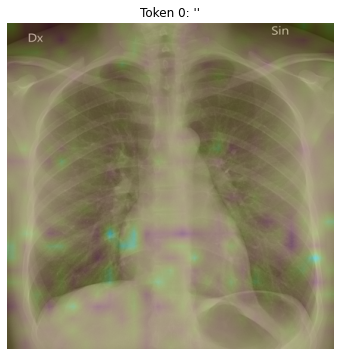

In [48]:
import torch
import torch.nn.functional as F
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
# === Paths ===
model_path = "blip-finetuned-roco"
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# === Load processor and model ===
processor = BlipProcessor.from_pretrained(model_path)
model = BlipForConditionalGeneration.from_pretrained(model_path).to("cuda" if torch.cuda.is_available() else "cpu")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

# === Load image ===
image_path = "/scratch/klimbu2/Final_Project/test.jpg"
raw_image = Image.open(image_path).convert("RGB")
image_tensor = processor(images=raw_image, return_tensors="pt")["pixel_values"][0]
H, W = raw_image.size

# === Hook for attention maps ===
attention_maps = []

def save_attention_hook(module, input, output):
    attention_maps.append(output)

# Register hook to decoder cross-attention
for block in model.text_decoder.bert.encoder.layer:
    block.crossattention.self.register_forward_hook(save_attention_hook)

# === Generate caption ===
inputs = processor(images=raw_image, return_tensors="pt").to(device)
attention_maps.clear()
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=20)

# === Decode caption ===
caption = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
tokens = processor.tokenizer.convert_ids_to_tokens(output_ids[0])
print("Caption:", caption)

# === Process and visualize attention maps ===
if not attention_maps:
    print("No attention maps were captured.")
else:
    # Get last layer attention: [1, heads, tgt_len, src_len]
    attn_tensor = attention_maps[-1][0]  # shape: [heads, tgt_len, src_len]
    attn_avg = attn_tensor.mean(dim=0)   # average over heads → [tgt_len, src_len]

    num_tokens = attn_avg.shape[0]
    num_patches = attn_avg.shape[1] - 1  # Exclude CLS token
    patch_size = int(np.sqrt(num_patches))
    image_np = np.array(raw_image.resize((patch_size*16, patch_size*16)))  # upscale to fit patch grid

    for i in range(num_tokens):
        token_id = output_ids[0][i].item()
        token_str = processor.tokenizer.decode(token_id)
        if token_str in ["<pad>", "</s>"]:
            continue
            
        weights = attn_avg[i, 1:]  # Drop CLS token
        weights = F.softmax(weights, dim=0).cpu().numpy()
        weights = (weights - weights.min()) / (weights.max() - weights.min())

        try:
            attn_map = weights[:patch_size * patch_size].reshape(patch_size, patch_size)
            attn_map = cv2.resize(attn_map, (image_np.shape[1], image_np.shape[0]))
            attn_map = np.uint8(255 * attn_map)
            attn_color = cv2.applyColorMap(attn_map, cv2.COLORMAP_VIRIDIS)
            overlay = cv2.addWeighted(image_np, 0.6, attn_color, 0.4, 0)

            plt.figure(figsize=(6, 6))
            plt.imshow(overlay)
            plt.title(f"Token {i}: '{token_str}'")
            plt.axis("off")
            # plt.savefig("attention.jpg")
            plt.savefig(f"attention_no_freezing_{i}_{token_str.strip().replace('/', '_')}.jpg")

            plt.show()
        except Exception as e:
            print(f"Token {i} skipped due to error: {e}")


# BLIP Fine-tune Decoder Only

In [10]:
import torch
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.cuda.amp import autocast, GradScaler
from transformers import BlipForConditionalGeneration, get_scheduler
from transformers import default_data_collator
from torch.utils.data import DataLoader
from datasets import load_from_disk
from tqdm import tqdm

# === Config ===
DATA_PATH = "processed_roco_final"
BATCH_SIZE = 8
GRAD_ACCUM = 4
EPOCHS = 1
LEARNING_RATE = 5e-5
MODEL_SAVE_PATH = "blip-finetuned-roco-decoder-only"

# === Load dataset ===
dataset = load_from_disk(DATA_PATH)
dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=default_data_collator
)

# === Load BLIP and freeze vision encoder ===
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Freeze vision encoder (ViT)
for param in model.vision_model.parameters():
    param.requires_grad = False

# === Optimizer & Scheduler ===
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
num_training_steps = len(dataloader) * EPOCHS // GRAD_ACCUM
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

scaler = GradScaler()

# === Training Loop ===
model.train()
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader))

    for step, batch in progress_bar:
        try:
            batch = {k: v.to(device) for k, v in batch.items()}

            with autocast():
                outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    pixel_values=batch["pixel_values"],
                    labels=batch["input_ids"]
                )
                loss = outputs.loss / GRAD_ACCUM

            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(dataloader):
                clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                lr_scheduler.step()

            progress_bar.set_description(f"Epoch {epoch+1}")
            progress_bar.set_postfix(loss=round(loss.item() * GRAD_ACCUM, 4))

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print("Skipping batch due to OOM")
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
            else:
                raise e

# === Save model ===
model.save_pretrained(MODEL_SAVE_PATH)
print(f"\nModel saved to: {MODEL_SAVE_PATH}")


Loading dataset from disk:   0%|          | 0/233 [00:00<?, ?it/s]


--- Epoch 1/1 ---


Epoch 1: 100%|██████████| 8178/8178 [4:59:37<00:00,  2.20s/it, loss=1.86]   



✅ Model saved to: blip-finetuned-roco-decoder-only


## BLIP Fine-tune - Decoder Only Evaluation

In [22]:
import os
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Allows PIL to load broken images

# --- Load ground truth captions from .txt file ---
def load_roco_captions(txt_path):
    gt = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                image_id, caption = parts
                if caption.strip():  # Ensure caption isn't empty
                    gt[image_id + ".jpg"] = caption.strip()
    return gt

# Paths
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# Load captions
gt_captions = load_roco_captions(captions_txt_path)
image_list = [
    fname for fname in gt_captions.keys()
    if os.path.exists(os.path.join(image_dir, fname))
]

In [28]:
import os
import json
from PIL import Image, ImageFile
from tqdm import tqdm
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

ImageFile.LOAD_TRUNCATED_IMAGES = True

# === Paths ===
model_path = "blip-finetuned-roco-decoder-only"
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# === Load processor and model ===
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base") 
model = BlipForConditionalGeneration.from_pretrained(model_path).to(model.device)
model.eval()

# === Load test image-caption pairs ===
def load_roco_captions(txt_path):
    gt = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                image_id, caption = parts
                if caption.strip():
                    gt[image_id + ".jpg"] = caption.strip()
    return gt

gt_captions = load_roco_captions(captions_txt_path)
image_list = [
    fname for fname in gt_captions.keys()
    if os.path.exists(os.path.join(image_dir, fname))
]

# === Generate captions ===
generated = {}
for fname in tqdm(image_list, desc="Generating captions"):
    try:
        image = Image.open(os.path.join(image_dir, fname)).convert("RGB")
        inputs = processor(image, "a medical scan", return_tensors="pt").to(model.device)
        output = model.generate(**inputs)
        caption = processor.decode(output[0], skip_special_tokens=True)
        generated[fname] = [caption]
    except Exception as e:
        print(f"Skipping {fname}: {e}")

# === Save output ===
with open("generated_encoder_freezed_finetuned_captions.json", "w") as f:
    json.dump(generated, f)

print("Captions generated and saved to generated_finetuned_captions.json")

Generating captions: 100%|██████████| 8176/8176 [29:44<00:00,  4.58it/s]

Captions generated and saved to generated_finetuned_captions.json


In [35]:
import json

with open("generated_encoder_freezed_finetuned_captions.json", "r") as gen_f:
    generated_finetuned = json.load(gen_f)

with open("reference_captions.json", "r") as ref_f:
    references = json.load(ref_f)

In [36]:
import os
import sys
import json
import torch
import logging
import warnings
import tempfile
import contextlib
from tqdm import tqdm
from numpy import ndarray
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from bert_score import score
# === COCOEvalCap (CIDEr & SPICE only) ===
from pycocoevalcap.eval import COCOEvalCap
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocotools.coco import COCO
import io

# Suppress warnings & transformers logs
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# === Bio_ClinicalBERT Setup ===
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# === Sentence Embedding Function (mean-pooled) ===
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden = outputs.last_hidden_state
    mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
    masked = last_hidden * mask
    summed = masked.sum(1)
    counts = mask.sum(1)
    mean_pooled = summed / counts
    return mean_pooled.squeeze().cpu().numpy()

# === Inputs: preds, refs ===
# Replace with your actual values
preds = [generated_finetuned[k][0] for k in image_list]
refs = [references[k][0] for k in image_list]

# === Cosine Similarity (Mean-Pooled Bio_ClinicalBERT) ===
similarities = []
for pred, ref in tqdm(zip(preds, refs), total=len(preds), desc="Bio_ClinicalBERT Cosine"):
    try:
        emb_pred = get_embedding(pred)
        emb_ref = get_embedding(ref)
        if isinstance(emb_pred, ndarray) and isinstance(emb_ref, ndarray) and emb_pred.shape == emb_ref.shape:
            sim = cosine_similarity([emb_pred], [emb_ref])[0][0]
        else:
            sim = 0.0
    except:
        sim = 0.0
    similarities.append(sim)
bio_clinical_cosine = sum(similarities) / len(similarities)

# === BERTScore (Bio_ClinicalBERT & Original) ===
def truncate_to_512(texts, tokenizer):
    return [tokenizer.convert_tokens_to_string(tokenizer.tokenize(t)[:510]) for t in texts]

preds_trunc = truncate_to_512(preds, tokenizer)
refs_trunc = truncate_to_512(refs, tokenizer)

P_Bio, R_Bio, F1_Bio = score(
    preds_trunc, refs_trunc,
    model_type=model_name,
    num_layers=12,
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

P_BERT, R_BERT, F1_BERT = score(
    preds, refs,
    model_type="bert-base-uncased",
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

pred_dict = {str(i): [pred] for i, pred in enumerate(preds)}
ref_dict  = {str(i): [ref] for i, ref in enumerate(refs)}

def prepare_coco_format(pred_dict, ref_dict):
    ann = {'annotations': [], 'images': [], 'type': 'captions', 'info': {}, 'licenses': []}
    for image_id in ref_dict:
        ann['images'].append({'id': image_id})
        for idx, caption in enumerate(ref_dict[image_id]):
            ann['annotations'].append({
                'image_id': image_id,
                'id': int(f"{image_id}{idx}"),
                'caption': caption
            })
    return ann, [{'image_id': k, 'caption': v[0]} for k, v in pred_dict.items()]

ann_file, res_file = tempfile.NamedTemporaryFile(delete=False), tempfile.NamedTemporaryFile(delete=False)
with open(ann_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[0], f)
with open(res_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[1], f)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    coco = COCO(ann_file.name)
    cocoRes = coco.loadRes(res_file.name)
    
tokenizer = PTBTokenizer()
coco.evalImgs = []
cocoEval = COCOEvalCap(coco, cocoRes)
cocoEval.params['eval'] = ['CIDEr', 'SPICE']

# === Suppress COCOEvalCap stdout/stderr ===
@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

with suppress_stdout_stderr():
    cocoEval.evaluate()

# === Final Clean Output ===
print(f"\n--- Evaluation Summary for Encoder Freeze Fine-Tuned BERT Model ---")
print(f"Bio_ClinicalBERT Cosine Similarity (Mean Pooled): {bio_clinical_cosine:.4f}")
print(f"BERTScore with Bio_ClinicalBERT:\n"
      f"\tPrecision: {P_Bio.mean():.4f}\n"
      f"\tRecall:    {R_Bio.mean():.4f}\n"
      f"\tF1-Score:  {F1_Bio.mean():.4f}")
print(f"Original BERTScore:\n"
      f"\tPrecision: {P_BERT.mean():.4f}\n"
      f"\tRecall:    {R_BERT.mean():.4f}\n"
      f"\tF1-Score:  {F1_BERT.mean():.4f}")
print(f"CIDEr: {cocoEval.eval['CIDEr']:.4f}")
print(f"SPICE: {cocoEval.eval['SPICE']:.4f}")

# === Cleanup
os.unlink(ann_file.name)
os.unlink(res_file.name)

Bio_ClinicalBERT Cosine: 100%|██████████| 8176/8176 [01:58<00:00, 69.09it/s]
May 04, 2025 11:04:52 PM edu.stanford.nlp.process.PTBLexer next
PTBTokenizer tokenized 200345 tokens at 1174041.60 tokens per second.
PTBTokenizer tokenized 144789 tokens at 1264558.51 tokens per second.
Parsing reference captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.3 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pi

SPICE evaluation took: 2.313 min

--- Evaluation Summary for Encoder Freeze Fine-Tuned BERT Model ---
Bio_ClinicalBERT Cosine Similarity (Mean Pooled): 0.8863
BERTScore with Bio_ClinicalBERT:
	Precision: 0.7433
	Recall:    0.7049
	F1-Score:  0.7228
Original BERTScore:
	Precision: 0.5478
	Recall:    0.4873
	F1-Score:  0.5132
CIDEr: 0.0664
SPICE: 0.0275


## BLIP Fine-tune - Deconder Only -> Attention Visualization

Caption: chest x - ray showing bilateral pleural effusion.


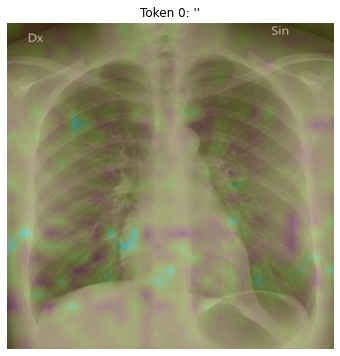

In [45]:
import torch
import torch.nn.functional as F
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2
# ===== Load model, images, captions ====
model_path = "blip-finetuned-roco-decoder-only"
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# === Load processor and model ===
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base") 
model = BlipForConditionalGeneration.from_pretrained(model_path).to(model.device)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

# === Load image ===
image_path = "/scratch/klimbu2/Final_Project/test.jpg"
raw_image = Image.open(image_path).convert("RGB")
image_tensor = processor(images=raw_image, return_tensors="pt")["pixel_values"][0]
H, W = raw_image.size

# === Hook for attention maps ===
attention_maps = []

def save_attention_hook(module, input, output):
    attention_maps.append(output)

# Register hook to decoder cross-attention
for block in model.text_decoder.bert.encoder.layer:
    block.crossattention.self.register_forward_hook(save_attention_hook)

# === Generate caption ===
inputs = processor(images=raw_image, return_tensors="pt").to(device)
attention_maps.clear()
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=20)

# === Decode caption ===
caption = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
tokens = processor.tokenizer.convert_ids_to_tokens(output_ids[0])
print("Caption:", caption)

# === Process and visualize attention maps ===
if not attention_maps:
    print("No attention maps were captured.")
else:
    # Get last layer attention: [1, heads, tgt_len, src_len]
    attn_tensor = attention_maps[-1][0]  # shape: [heads, tgt_len, src_len]
    attn_avg = attn_tensor.mean(dim=0)   # average over heads → [tgt_len, src_len]

    num_tokens = attn_avg.shape[0]
    num_patches = attn_avg.shape[1] - 1  # Exclude CLS token
    patch_size = int(np.sqrt(num_patches))
    image_np = np.array(raw_image.resize((patch_size*16, patch_size*16)))  # upscale to fit patch grid

    for i in range(num_tokens):
        token_id = output_ids[0][i].item()
        token_str = processor.tokenizer.decode(token_id)
        if token_str in ["<pad>", "</s>"]:
            continue
            
        weights = attn_avg[i, 1:]  # Drop CLS token
        weights = F.softmax(weights, dim=0).cpu().numpy()
        weights = (weights - weights.min()) / (weights.max() - weights.min())

        try:
            attn_map = weights[:patch_size * patch_size].reshape(patch_size, patch_size)
            attn_map = cv2.resize(attn_map, (image_np.shape[1], image_np.shape[0]))
            attn_map = np.uint8(255 * attn_map)
            attn_color = cv2.applyColorMap(attn_map, cv2.COLORMAP_VIRIDIS)
            overlay = cv2.addWeighted(image_np, 0.6, attn_color, 0.4, 0)

            plt.figure(figsize=(6, 6))
            plt.imshow(overlay)
            plt.title(f"Token {i}: '{token_str}'")
            plt.axis("off")
            # plt.savefig("attention.jpg")
            plt.savefig(f"attention_freeze_encoder_only_{i}_{token_str.strip().replace('/', '_')}.jpg")

            plt.show()
        except Exception as e:
            print(f"Token {i} skipped due to error: {e}")


# BLIP Fine-tine - Encoder Only

In [ ]:
import torch
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.cuda.amp import autocast, GradScaler

# from transformers import BlipForConditionalGeneration, get_scheduler, default_data_collator
# from tqdm import tqdm
# from torch.utils.data import DataLoader
# from datasets import load_from_disk
# # === Config ===
# DATA_PATH = "processed_roco_final"
# BATCH_SIZE = 8
# GRAD_ACCUM = 4import torch
# from torch.optim import AdamW
# from torch.nn.utils import clip_grad_norm_
# from torch.cuda.amp import autocast, GradScaler

from transformers import BlipForConditionalGeneration, get_scheduler, default_data_collator
from tqdm import tqdm
from torch.utils.data import DataLoader
from datasets import load_from_disk

# === Config ===
DATA_PATH = "processed_roco_final"
BATCH_SIZE = 8
GRAD_ACCUM = 4
EPOCHS = 1
LEARNING_RATE = 5e-5
MODEL_SAVE_PATH = "blip-encoderonly-roco"

# === Load dataset ===
dataset = load_from_disk(DATA_PATH)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=default_data_collator
)

# === Load model ===
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === Freeze decoder ===
for name, param in model.named_parameters():
    if "language_model" in name:
        param.requires_grad = False

# === Optimizer and Scheduler ===
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
num_training_steps = len(dataloader) * EPOCHS // GRAD_ACCUM
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)
scaler = GradScaler()

# === Training loop ===
model.train()
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    progress_bar = tqdm(dataloader, total=len(dataloader))

    for step, batch in enumerate(progress_bar):
        try:
            batch = {k: v.to(device) for k, v in batch.items()}

            with autocast():
                outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    pixel_values=batch["pixel_values"],
                    labels=batch["input_ids"]
                )
                loss = outputs.loss / GRAD_ACCUM

            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(dataloader):
                clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                lr_scheduler.step()

            progress_bar.set_description(f"Epoch {epoch+1}")
            progress_bar.set_postfix(loss=round(loss.item() * GRAD_ACCUM, 4))

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print("Skipping batch due to OOM")
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
            else:
                raise e

# === Save the model ===
model.save_pretrained(MODEL_SAVE_PATH)
print(f"\n Model saved to: {MODEL_SAVE_PATH}")

EPOCHS = 1
LEARNING_RATE = 5e-5
MODEL_SAVE_PATH = "blip-encoderonly-roco"

# === Load dataset ===
dataset = load_from_disk(DATA_PATH)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=default_data_collator
)

# === Load model ===
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# === Freeze decoder ===
for name, param in model.named_parameters():
    if "language_model" in name:
        param.requires_grad = False

# === Optimizer and Scheduler ===
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
num_training_steps = len(dataloader) * EPOCHS // GRAD_ACCUM
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)
scaler = GradScaler()

# === Training loop ===
model.train()
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    progress_bar = tqdm(dataloader, total=len(dataloader))

    for step, batch in enumerate(progress_bar):
        try:
            batch = {k: v.to(device) for k, v in batch.items()}

            with autocast():
                outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    pixel_values=batch["pixel_values"],
                    labels=batch["input_ids"]
                )
                loss = outputs.loss / GRAD_ACCUM

            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(dataloader):
                clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                lr_scheduler.step()

            progress_bar.set_description(f"Epoch {epoch+1}")
            progress_bar.set_postfix(loss=round(loss.item() * GRAD_ACCUM, 4))

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print("Skipping batch due to OOM")
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
            else:
                raise e

# === Save the model ===
model.save_pretrained(MODEL_SAVE_PATH)
print(f"\n Model saved to: {MODEL_SAVE_PATH}")


## BLIP Fine-tune - Encoder Only Evaluation

In [37]:
import os
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Allows PIL to load broken images

# --- Load ground truth captions from .txt file ---
def load_roco_captions(txt_path):
    gt = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                image_id, caption = parts
                if caption.strip():  # Ensure caption isn't empty
                    gt[image_id + ".jpg"] = caption.strip()
    return gt

# Paths
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# Load captions
gt_captions = load_roco_captions(captions_txt_path)
image_list = [
    fname for fname in gt_captions.keys()
    if os.path.exists(os.path.join(image_dir, fname))
]

In [38]:
import os
import json
from PIL import Image, ImageFile
from tqdm import tqdm
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration

ImageFile.LOAD_TRUNCATED_IMAGES = True

# === Paths ===
model_path = "blip-encoderonly-roco"
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# === Load processor and model ===
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")  
model = BlipForConditionalGeneration.from_pretrained(model_path).to(model.device)
model.eval()

# === Load test image-caption pairs ===
def load_roco_captions(txt_path):
    gt = {}
    with open(txt_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')
            if len(parts) == 2:
                image_id, caption = parts
                if caption.strip():
                    gt[image_id + ".jpg"] = caption.strip()
    return gt

gt_captions = load_roco_captions(captions_txt_path)
image_list = [
    fname for fname in gt_captions.keys()
    if os.path.exists(os.path.join(image_dir, fname))
]

# === Generate captions ===
generated = {}
for fname in tqdm(image_list, desc="Generating captions"):
    try:
        image = Image.open(os.path.join(image_dir, fname)).convert("RGB")
        inputs = processor(image, "a medical scan", return_tensors="pt").to(model.device)
        output = model.generate(**inputs)
        caption = processor.decode(output[0], skip_special_tokens=True)
        generated[fname] = [caption]
    except Exception as e:
        print(f"Skipping {fname}: {e}")

# === Save output ===
with open("generated_decoder_freezed_finetuned_captions.json", "w") as f:
    json.dump(generated, f)

print("Captions generated and saved to generated_finetuned_captions.json")

Generating captions: 100%|██████████| 8176/8176 [29:16<00:00,  4.65it/s]

Captions generated and saved to generated_finetuned_captions.json


In [39]:
import json

with open("generated_decoder_freezed_finetuned_captions.json", "r") as gen_f:
    generated_finetuned = json.load(gen_f)

with open("reference_captions.json", "r") as ref_f:
    references = json.load(ref_f)

In [40]:
import os
import sys
import json
import torch
import logging
import warnings
import tempfile
import contextlib
from tqdm import tqdm
from numpy import ndarray
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, AutoModel
from bert_score import score
# === COCOEvalCap (CIDEr & SPICE only) ===
from pycocoevalcap.eval import COCOEvalCap
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer
from pycocotools.coco import COCO
import io

# Suppress warnings & transformers logs
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

# === Bio_ClinicalBERT Setup ===
model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to("cuda" if torch.cuda.is_available() else "cpu")
model.eval()

# === Sentence Embedding Function (mean-pooled) ===
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden = outputs.last_hidden_state
    mask = inputs['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
    masked = last_hidden * mask
    summed = masked.sum(1)
    counts = mask.sum(1)
    mean_pooled = summed / counts
    return mean_pooled.squeeze().cpu().numpy()

# === Inputs: preds, refs ===
# Replace with your actual values
preds = [generated_finetuned[k][0] for k in image_list]
refs = [references[k][0] for k in image_list]

# === Cosine Similarity (Mean-Pooled Bio_ClinicalBERT) ===
similarities = []
for pred, ref in tqdm(zip(preds, refs), total=len(preds), desc="Bio_ClinicalBERT Cosine"):
    try:
        emb_pred = get_embedding(pred)
        emb_ref = get_embedding(ref)
        if isinstance(emb_pred, ndarray) and isinstance(emb_ref, ndarray) and emb_pred.shape == emb_ref.shape:
            sim = cosine_similarity([emb_pred], [emb_ref])[0][0]
        else:
            sim = 0.0
    except:
        sim = 0.0
    similarities.append(sim)
bio_clinical_cosine = sum(similarities) / len(similarities)

# === BERTScore (Bio_ClinicalBERT & Original) ===
def truncate_to_512(texts, tokenizer):
    return [tokenizer.convert_tokens_to_string(tokenizer.tokenize(t)[:510]) for t in texts]

preds_trunc = truncate_to_512(preds, tokenizer)
refs_trunc = truncate_to_512(refs, tokenizer)

P_Bio, R_Bio, F1_Bio = score(
    preds_trunc, refs_trunc,
    model_type=model_name,
    num_layers=12,
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

P_BERT, R_BERT, F1_BERT = score(
    preds, refs,
    model_type="bert-base-uncased",
    lang="en",
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=False
)

pred_dict = {str(i): [pred] for i, pred in enumerate(preds)}
ref_dict  = {str(i): [ref] for i, ref in enumerate(refs)}

def prepare_coco_format(pred_dict, ref_dict):
    ann = {'annotations': [], 'images': [], 'type': 'captions', 'info': {}, 'licenses': []}
    for image_id in ref_dict:
        ann['images'].append({'id': image_id})
        for idx, caption in enumerate(ref_dict[image_id]):
            ann['annotations'].append({
                'image_id': image_id,
                'id': int(f"{image_id}{idx}"),
                'caption': caption
            })
    return ann, [{'image_id': k, 'caption': v[0]} for k, v in pred_dict.items()]

ann_file, res_file = tempfile.NamedTemporaryFile(delete=False), tempfile.NamedTemporaryFile(delete=False)
with open(ann_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[0], f)
with open(res_file.name, 'w') as f:
    json.dump(prepare_coco_format(pred_dict, ref_dict)[1], f)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    coco = COCO(ann_file.name)
    cocoRes = coco.loadRes(res_file.name)
    
tokenizer = PTBTokenizer()
coco.evalImgs = []
cocoEval = COCOEvalCap(coco, cocoRes)
cocoEval.params['eval'] = ['CIDEr', 'SPICE']

# === Suppress COCOEvalCap stdout/stderr ===
@contextlib.contextmanager
def suppress_stdout_stderr():
    with open(os.devnull, 'w') as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

with suppress_stdout_stderr():
    cocoEval.evaluate()

# === Final Clean Output ===
print(f"\n--- Evaluation Summary for Decoder Freeze Fine-Tuned BERT Model ---")
print(f"Bio_ClinicalBERT Cosine Similarity (Mean Pooled): {bio_clinical_cosine:.4f}")
print(f"BERTScore with Bio_ClinicalBERT:\n"
      f"\tPrecision: {P_Bio.mean():.4f}\n"
      f"\tRecall:    {R_Bio.mean():.4f}\n"
      f"\tF1-Score:  {F1_Bio.mean():.4f}")
print(f"Original BERTScore:\n"
      f"\tPrecision: {P_BERT.mean():.4f}\n"
      f"\tRecall:    {R_BERT.mean():.4f}\n"
      f"\tF1-Score:  {F1_BERT.mean():.4f}")
print(f"CIDEr: {cocoEval.eval['CIDEr']:.4f}")
print(f"SPICE: {cocoEval.eval['SPICE']:.4f}")

# === Cleanup
os.unlink(ann_file.name)
os.unlink(res_file.name)

Bio_ClinicalBERT Cosine: 100%|██████████| 8176/8176 [01:55<00:00, 70.49it/s]
May 04, 2025 11:52:09 PM edu.stanford.nlp.process.PTBLexer next
PTBTokenizer tokenized 200345 tokens at 767018.09 tokens per second.
PTBTokenizer tokenized 142792 tokens at 1116902.55 tokens per second.
Parsing reference captions
Initiating Stanford parsing pipeline
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator tokenize
[main] INFO edu.stanford.nlp.pipeline.TokenizerAnnotator - TokenizerAnnotator: No tokenizer type provided. Defaulting to PTBTokenizer.
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator ssplit
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator parse
[main] INFO edu.stanford.nlp.parser.common.ParserGrammar - Loading parser from serialized file edu/stanford/nlp/models/lexparser/englishPCFG.ser.gz ... 
done [0.4 sec].
[main] INFO edu.stanford.nlp.pipeline.StanfordCoreNLP - Adding annotator lemma
[main] INFO edu.stanford.nlp.pip

SPICE evaluation took: 2.830 min

--- Evaluation Summary for Decoder Freeze Fine-Tuned BERT Model ---
Bio_ClinicalBERT Cosine Similarity (Mean Pooled): 0.8925
BERTScore with Bio_ClinicalBERT:
	Precision: 0.7501
	Recall:    0.7103
	F1-Score:  0.7289
Original BERTScore:
	Precision: 0.5558
	Recall:    0.4932
	F1-Score:  0.5200
CIDEr: 0.0822
SPICE: 0.0356


## BLIP - Freeze Decoder Evaluation

In [ ]:
import torch
import torch.nn.functional as F
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

# === Paths ===
model_path = "blip-encoderonly-roco" # freeze decoder
image_dir = "roco-dataset-master/data/test/radiology/images"
captions_txt_path = "roco-dataset-master/data/test/radiology/captions.txt"

# === Load processor and model ===
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")  
model = BlipForConditionalGeneration.from_pretrained(model_path).to(model.device)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.eval()

# === Load image ===
image_path = "/scratch/klimbu2/Final_Project/test.jpg"
raw_image = Image.open(image_path).convert("RGB")
image_tensor = processor(images=raw_image, return_tensors="pt")["pixel_values"][0]
H, W = raw_image.size

# === Hook for attention maps ===
attention_maps = []

def save_attention_hook(module, input, output):
    attention_maps.append(output)

# Register hook to decoder cross-attention
for block in model.text_decoder.bert.encoder.layer:
    block.crossattention.self.register_forward_hook(save_attention_hook)

# === Generate caption ===
inputs = processor(images=raw_image, return_tensors="pt").to(device)
attention_maps.clear()
with torch.no_grad():
    output_ids = model.generate(**inputs, max_new_tokens=20)

# === Decode caption ===
caption = processor.batch_decode(output_ids, skip_special_tokens=True)[0]
tokens = processor.tokenizer.convert_ids_to_tokens(output_ids[0])
print("Caption:", caption)

# === Process and visualize attention maps ===
if not attention_maps:
    print("No attention maps were captured.")
else:
    # Get last layer attention: [1, heads, tgt_len, src_len]
    attn_tensor = attention_maps[-1][0]  # shape: [heads, tgt_len, src_len]
    attn_avg = attn_tensor.mean(dim=0)   # average over heads → [tgt_len, src_len]

    num_tokens = attn_avg.shape[0]
    num_patches = attn_avg.shape[1] - 1  # Exclude CLS token
    patch_size = int(np.sqrt(num_patches))
    image_np = np.array(raw_image.resize((patch_size*16, patch_size*16)))  # upscale to fit patch grid

    for i in range(num_tokens):
        token_id = output_ids[0][i].item()
        token_str = processor.tokenizer.decode(token_id)
        if token_str in ["<pad>", "</s>"]:
            continue
            
        weights = attn_avg[i, 1:]  # Drop CLS token
        weights = F.softmax(weights, dim=0).cpu().numpy()
        weights = (weights - weights.min()) / (weights.max() - weights.min())

        try:
            attn_map = weights[:patch_size * patch_size].reshape(patch_size, patch_size)
            attn_map = cv2.resize(attn_map, (image_np.shape[1], image_np.shape[0]))
            attn_map = np.uint8(255 * attn_map)
            attn_color = cv2.applyColorMap(attn_map, cv2.COLORMAP_VIRIDIS)
            overlay = cv2.addWeighted(image_np, 0.6, attn_color, 0.4, 0)

            plt.figure(figsize=(6, 6))
            plt.imshow(overlay)
            plt.title(f"Token {i}: '{token_str}'")
            plt.axis("off")
            # plt.savefig("attention.jpg")
            plt.savefig(f"attention_freeze_decoder_only_{i}_{token_str.strip().replace('/', '_')}.jpg")

            plt.show()
        except Exception as e:
            print(f"Token {i} skipped due to error: {e}")


In [3]:
# pip install peft
!pip install transformers peft accelerate bitsandbytes


Defaulting to user installation because normal site-packages is not writeable


# PEFT - LORA (Not working)

In [ ]:
import os
import torch
from torch.optim import AdamW
from torch.nn.utils import clip_grad_norm_
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import DataLoader
from datasets import load_from_disk
from tqdm import tqdm

from transformers import (
    BlipForConditionalGeneration,
    BlipProcessor,
    get_scheduler,
    default_data_collator,
)
from peft import get_peft_model, LoraConfig, TaskType, PeftModelForSeq2SeqLM

# === Config ===
DATA_PATH = "processed_roco_final"
MODEL_SAVE_PATH = "blip-lora-roco"
BATCH_SIZE = 8
GRAD_ACCUM = 4
EPOCHS = 1
LEARNING_RATE = 5e-5

# === Load Dataset ===
dataset = load_from_disk(DATA_PATH)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=default_data_collator
)

# === Load base BLIP model and processor ===
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")


# === Correct LoRA Configuration ===
lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["q", "v"],  # Works for BLIP's decoder architecture
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.SEQ_2_SEQ_LM,
    inference_mode=False
)

# === Special forward pass adaptation ===
class BlipLoraWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, pixel_values, labels):
        return self.model(
            pixel_values=pixel_values,
            labels=labels,
            decoder_input_ids=labels[:, :-1],  # BLIP requires explicit decoder inputs
            decoder_attention_mask=(labels[:, :-1] != model.config.pad_token_id)
        )

# === Apply LoRA and wrapper ===
model = get_peft_model(model, lora_config)
model = BlipLoraWrapper(model)

# === Optimizer, Scheduler, Device ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LEARNING_RATE)
num_training_steps = len(dataloader) * EPOCHS // GRAD_ACCUM
lr_scheduler = get_scheduler("linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)
scaler = GradScaler()

# === Training Loop ===

# === Training Loop ===
model.train()
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")
    progress_bar = tqdm(enumerate(dataloader), total=len(dataloader))

    for step, batch in progress_bar:
        try:
            batch = {k: v.to(device) for k, v in batch.items()}

            with autocast():
                # Explicitly filter valid BLIP arguments
                outputs = model(
                    pixel_values=batch["pixel_values"],
                    labels=batch["input_ids"],
                    decoder_attention_mask=batch.get("attention_mask", None)
                )
                loss = outputs.loss / GRAD_ACCUM

            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(dataloader):
                clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                lr_scheduler.step()

            progress_bar.set_description(f"Epoch {epoch + 1}")
            progress_bar.set_postfix(loss=round(loss.item() * GRAD_ACCUM, 4))

        except RuntimeError as e:
            if "CUDA out of memory" in str(e):
                print("Skipping batch due to OOM")
                optimizer.zero_grad(set_to_none=True)
                torch.cuda.empty_cache()
            else:
                raise e

# === Save LoRA-augmented Model Only ===
model.save_pretrained(MODEL_SAVE_PATH)
print(f"\nLoRA-augmented BLIP model saved to: {MODEL_SAVE_PATH}")

## Our Contribution
### 1. Fine-tuning Type

-> (Done) No fine-tuning - BLIP base (zero-shot)

-> (Done) Full fine-tuning - Fine-tune both

-> (Done) Decoder-only fine-tuning - Freeze vision encoder, train only decoder

-> (Done) Vision encoder only fine-tuning - Freeze language decoder, adapt visual part

-> (Optional) PEFT - LoRA - Didn't work at all

2. Robustness / Generalization Tests
Try your fine-tuned model on:

ROCO non-radiology data

External medical datasets (IU-Chest X-rays)

Ambiguous/long captions
3. Cross attention Visualization
4. Evaluatin Metrics 
BERTScore (Bio_ClinicalBERT)

CIDEr, BLEU-4, ROUGE-L

Optional: CLIPScore, ClinicalBLEURT, SPICE

5. Pretraining Transfer Analysis (Comparative Analysis)

BLIP base

Zero-shot BLIP2

Or any CNN+LSTM baseline